# LSEG Data Pull

Dieses Notebook baut den zentralen Datenblock für die spätere Portfolio- und Duration-Analyse auf.

Enthalten sind drei Bausteine:
1. Laden der vorbereiteten Euro500-Parquet-Dateien
2. Schätzung eines robusten täglichen CAPM-Betas je Firma (rolling)
3. As-of Pull von Analysten-EPS-Forecasts (FY1-FY5) über LSEG

Am Ende liegt ein EPS-Panel auf Firmen-Datum-Ebene vor, das direkt in die weiteren Notebooks gemerged werden kann.


## 0. Setup

Was hier passiert:
- Standardbibliotheken laden (`numpy`, `pandas`, `pathlib`)
- LSEG SDK (`lseg.data`) importieren
- Projektpfade setzen (`BASE_DIR`, `DATA_DIR`)
- Anzeige- und Warning-Optionen für reproduzierbare Notebook-Ausgaben konfigurieren

Hinweis:
- Das Notebook erwartet die vorbereiteten Input-Dateien in `Project_Data/intermediate`.
- Für den EPS-Pull muss die LSEG-Session lokal erreichbar sein.


In [18]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import lseg.data as ld

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 120)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"

import hashlib
import json
import random
import re
import time
import matplotlib.pyplot as plt


## 1. Parquet-Dateien laden

Geladene Inputs:
- `euro500.parquet`: Stammdaten/Universe je Firma und Stichtag
- `euro500_returns.parquet`: Markt-/Aggregate-Renditen
- `daily_returns_euro500_in_index.parquet`: tägliche Firmenrenditen im Index-Universum

Ziel dieses Schritts:
- Konsistente Ausgangstabellen im Speicher bereitstellen
- Frühzeitig mit `FileNotFoundError` abbrechen, falls Inputs fehlen


In [19]:
EURO500_PATH = DATA_DIR / "euro500.parquet"
EURO500_RETURNS_PATH = DATA_DIR / "euro500_returns.parquet"
DAILY_RETURNS_IN_INDEX_PATH = DATA_DIR / "daily_returns_euro500_in_index.parquet"

for p in [EURO500_PATH, EURO500_RETURNS_PATH, DAILY_RETURNS_IN_INDEX_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")

euro500 = pd.read_parquet(EURO500_PATH)
euro500_returns = pd.read_parquet(EURO500_RETURNS_PATH)
daily_returns_euro500_in_index = pd.read_parquet(DAILY_RETURNS_IN_INDEX_PATH)

print("Loaded:")
print("- euro500:", euro500.shape)
print("- euro500_returns:", euro500_returns.shape)
print("- daily_returns_euro500_in_index:", daily_returns_euro500_in_index.shape)


Loaded:
- euro500: (54000, 22)
- euro500_returns: (7016, 8)
- daily_returns_euro500_in_index: (3336240, 12)


## 2. Beta (täglich, rolling)

Marktreferenz:
- `market_return_ffmcap_capped80` aus `euro500_returns`

Was berechnet wird:
- Firmenspezifisches tägliches CAPM-Beta auf rollender Basis
- Standardfenster: `252` Handelstage, Mindestbeobachtung: `126`

Warum dieser Schritt wichtig ist:
- Liefert ein zeitvariierendes Risikomaß je Firma
- Wird in Folgeanalysen als Kontroll- bzw. Strukturvariable genutzt


### Definition der Beta-Schätzung

Wir schätzen ein **tägliches firmenspezifisches CAPM-Beta** als rolling Kennzahl je Firma `i`:

$$
\beta_{i,t} = \frac{\operatorname{Cov}_{W}(r_{i}, r_{m})}{\operatorname{Var}_{W}(r_{m})}
$$

mit:
- `r_i`: tägliche Firmenrendite (`ret`)
- `r_m`: tägliche Marktrendite (`market_ret_cap80` = `market_return_ffmcap_capped80`)
- `W`: rolling Fenster mit `BETA_WINDOW = 252` Handelstagen und `BETA_MIN_OBS = 126`

Implementierungsdetails (momentenbasiert, identisch zur Kovarianz/Varianz-Formel):

$$
\operatorname{Cov}_{W}(r_i,r_m)=E_W[r_i r_m]-E_W[r_i]E_W[r_m],
\qquad
\operatorname{Var}_{W}(r_m)=E_W[r_m^2]-E_W[r_m]^2
$$

Dann gilt in Code:
- `cov_im = mean_im - (mean_i * mean_m)`
- `var_m = mean_m2 - (mean_m ** 2)`
- `beta_capm_daily = cov_im / var_m` für `var_m > 0`, sonst `NaN`.

### QC-Filter (direkt auf `beta_capm_daily`)

Die gespeicherte Spalte `beta_capm_daily` ist bereits gefiltert mit:
- `n_firms_day >= 300`
- `var_m_roll >= 1e-6`
- `|beta_capm_daily| <= 3`

Bei Nichterfüllung wird **kein Datensatz gelöscht**; nur `beta_capm_daily` bleibt `NaN` (leer).


In [20]:
MARKET_COL = "market_return_ffmcap_capped80"
BETA_WINDOW = 252
BETA_MIN_OBS = 126

# QC parameter
MIN_FIRMS_DAY = 300
MIN_VAR_M_ROLL = 1e-6
MAX_ABS_BETA = 3.0

daily_returns = daily_returns_euro500_in_index.copy()
daily_returns["date"] = pd.to_datetime(daily_returns["date"], errors="coerce")
daily_returns["ret"] = pd.to_numeric(daily_returns["ret"], errors="coerce")

market_daily = euro500_returns[["date", MARKET_COL]].copy()
market_daily["date"] = pd.to_datetime(market_daily["date"], errors="coerce")
market_daily["market_ret_cap80"] = pd.to_numeric(market_daily[MARKET_COL], errors="coerce")
market_daily = market_daily[["date", "market_ret_cap80"]].drop_duplicates(subset=["date"])

daily_returns = daily_returns.merge(market_daily, on="date", how="left")
daily_returns = daily_returns.sort_values(["company_key", "date"]).reset_index(drop=True)

# Ensure firm_id exists (backward compatible with older daily_returns files).
if "firm_id" not in daily_returns.columns:
    fid = pd.Series(pd.NA, index=daily_returns.index, dtype="string")
    if "ISIN" in daily_returns.columns:
        v = daily_returns["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("ISIN:" + v)
    if "RIC_current" in daily_returns.columns:
        v = daily_returns["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "RIC" in daily_returns.columns:
        v = daily_returns["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "SEDOL" in daily_returns.columns:
        v = daily_returns["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("SEDOL:" + v)
    if "company_key" in daily_returns.columns:
        ck = daily_returns["company_key"].astype("string").str.strip()
        ck = ck.where(ck.notna() & (ck != ""), pd.NA)
        fid = fid.fillna(ck)
    daily_returns["firm_id"] = fid
else:
    daily_returns["firm_id"] = daily_returns["firm_id"].astype("string").str.strip()
    daily_returns.loc[daily_returns["firm_id"] == "", "firm_id"] = pd.NA

daily_returns["ret_x_m"] = daily_returns["ret"] * daily_returns["market_ret_cap80"]
daily_returns["mkt_sq"] = daily_returns["market_ret_cap80"] ** 2

g = daily_returns.groupby("company_key", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_m = mean_m2 - (mean_m ** 2)
daily_returns["var_m_roll"] = var_m

# Raw beta
daily_returns["beta_capm_daily"] = np.where(var_m > 0, cov_im / var_m, np.nan)

# Cross-sectional availability per day (for QC)
n_firms_day = (
    daily_returns.groupby("date", as_index=False)["company_key"]
    .nunique()
    .rename(columns={"company_key": "n_firms_day"})
)
daily_returns = daily_returns.merge(n_firms_day, on="date", how="left")

qc_ok = (
    (daily_returns["n_firms_day"] >= MIN_FIRMS_DAY)
    & (daily_returns["var_m_roll"] >= MIN_VAR_M_ROLL)
    & (daily_returns["beta_capm_daily"].abs() <= MAX_ABS_BETA)
)

# Keep rows; only beta becomes empty (NaN) if QC fails.
daily_returns["beta_capm_daily"] = daily_returns["beta_capm_daily"].where(qc_ok, np.nan)

# Ensure export schema columns exist (missing ones are filled with NA).
export_cols = [
    "date",
    "quarter",
    "ISIN",
    "RIC",
    "RIC_current",
    "firm_id",
    "company_key",
    "ret",
    "market_ret_cap80",
    "beta_capm_daily",
]
for col in export_cols:
    if col not in daily_returns.columns:
        daily_returns[col] = pd.NA

daily_company_data = daily_returns[export_cols].copy()

DAILY_COMPANY_DATA_PATH = DATA_DIR / "daily_returns_beta.parquet"
daily_company_data.to_parquet(DAILY_COMPANY_DATA_PATH, index=False)

print("Saved:", DAILY_COMPANY_DATA_PATH)
print("Rows:", len(daily_company_data))
print("Date range:", daily_company_data["date"].min(), "to", daily_company_data["date"].max())
print("Beta non-null share (after QC):", round(daily_company_data["beta_capm_daily"].notna().mean(), 4))
daily_company_data.head()





Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_beta.parquet
Rows: 3336240
Date range: 1999-01-04 00:00:00 to 2026-02-13 00:00:00
Beta non-null share (after QC): 0.9411


,date,quarter,ISIN,RIC,RIC_current,firm_id,company_key,ret,market_ret_cap80,beta_capm_daily
0,2008-01-02,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,0.009647,-0.011095,NaN
1,2008-01-03,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,0.021143,-0.003918,NaN
2,2008-01-04,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,-0.01951,-0.016911,NaN
3,2008-01-07,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,-0.045279,-0.002236,NaN
4,2008-01-08,2008Q1,AT000000STR1,STRV.VI,STRV.VI,FIRM0000002,ISIN:AT000000STR1,0.007018,0.007045,NaN


## 2B. Beta-Analyse (Qualität der Schätzung)

Dieser Abschnitt ist reine Diagnostik und ändert keine Rohdaten.

Geprüft werden typischerweise:
- Abdeckung: Wie viele Firmen/Beobachtungen haben valides Beta?
- Stabilität: Verteilung und Ausreißer über Zeit
- Robustheit: Einfluss der QC-Filter (`min firms`, `min var`, `max |beta|`)

Ziel:
- Sicherstellen, dass die Betareihe ökonomisch plausibel und empirisch verwendbar ist.


In [21]:
analysis_df = daily_company_data.copy()
analysis_df = analysis_df.sort_values(["company_key", "date"]).reset_index(drop=True)

analysis_df["ret"] = pd.to_numeric(analysis_df["ret"], errors="coerce")
analysis_df["market_ret_cap80"] = pd.to_numeric(analysis_df["market_ret_cap80"], errors="coerce")
analysis_df["beta_capm_daily"] = pd.to_numeric(analysis_df["beta_capm_daily"], errors="coerce")

# Implied fit quality: R² aus rolling corr² (pro Firma, selbes Fenster wie Beta).
analysis_df["ret_sq"] = analysis_df["ret"] ** 2
analysis_df["ret_x_m"] = analysis_df["ret"] * analysis_df["market_ret_cap80"]
analysis_df["mkt_sq"] = analysis_df["market_ret_cap80"] ** 2

g = analysis_df.groupby("company_key", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_i2 = g["ret_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_i = mean_i2 - (mean_i ** 2)
var_m = mean_m2 - (mean_m ** 2)
den = np.sqrt(var_i * var_m)
corr_im = np.where(den > 0, cov_im / den, np.nan)
analysis_df["r2_capm_daily"] = np.clip(corr_im ** 2, 0, 1)

analysis_df["ret_hat"] = analysis_df["beta_capm_daily"] * analysis_df["market_ret_cap80"]
analysis_df["resid"] = analysis_df["ret"] - analysis_df["ret_hat"]
analysis_df["abs_err"] = (analysis_df["resid"]).abs()

n_firms_day = (
    analysis_df.groupby("date", as_index=False)["company_key"]
    .nunique()
    .rename(columns={"company_key": "n_firms_day"})
)
analysis_df = analysis_df.merge(n_firms_day, on="date", how="left")

summary = pd.DataFrame([
    {
        "rows": len(analysis_df),
        "companies": analysis_df["company_key"].nunique(),
        "beta_non_null_share": analysis_df["beta_capm_daily"].notna().mean(),
        "r2_non_null_share": analysis_df["r2_capm_daily"].notna().mean(),
        "beta_median": analysis_df["beta_capm_daily"].median(),
        "beta_p10": analysis_df["beta_capm_daily"].quantile(0.10),
        "beta_p90": analysis_df["beta_capm_daily"].quantile(0.90),
        "r2_median": analysis_df["r2_capm_daily"].median(),
        "r2_p90": analysis_df["r2_capm_daily"].quantile(0.90),
        "mae": analysis_df["abs_err"].mean(),
    }
])

print("Gesamt-Diagnostik:")
display(summary)

by_company = (
    analysis_df.groupby("company_key", as_index=False)
    .agg(
        n_obs=("beta_capm_daily", "size"),
        beta_non_null=("beta_capm_daily", lambda s: s.notna().sum()),
        beta_median=("beta_capm_daily", "median"),
        beta_std=("beta_capm_daily", "std"),
        r2_median=("r2_capm_daily", "median"),
        mae=("abs_err", "mean"),
    )
)
by_company["beta_availability"] = np.where(by_company["n_obs"] > 0, by_company["beta_non_null"] / by_company["n_obs"], np.nan)

print("Schwächste 10 Firmen nach medianem R²:")
display(by_company.sort_values(["r2_median", "beta_availability"]).head(10))

print("Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):")
display(by_company.sort_values(["r2_median", "beta_availability"], ascending=[False, False]).head(10))


Gesamt-Diagnostik:


,rows,companies,beta_non_null_share,r2_non_null_share,beta_median,beta_p10,beta_p90,r2_median,r2_p90,mae
0,3336240,1621,0.941126,0.944566,0.752335,0.184144,1.376809,0.165872,0.461036,0.012954


Schwächste 10 Firmen nach medianem R²:


,company_key,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
505,ISIN:ES0137998516,402,275,0.193686,0.182793,0.000020,0.033732,0.684080
1225,ISIN:IT0005611642,192,63,-0.004625,0.023550,0.000037,0.024027,0.328125
1401,ISIN:NL00150006Z9,193,68,0.015531,0.023501,0.000064,0.013889,0.352332
674,ISIN:FR0000039026,145,17,-0.029355,0.019121,0.000167,0.013324,0.117241
621,ISIN:FI0009900385,196,70,0.020625,0.054735,0.000201,0.026956,0.357143
389,ISIN:DE000A2YNT30,158,33,-0.068520,0.038593,0.000202,0.022704,0.208861
616,ISIN:FI0009800296,218,90,0.043602,0.102685,0.000224,0.024781,0.412844
7,ISIN:AT0000640552,1147,1021,-0.000448,0.090612,0.000268,0.013315,0.890148
240,ISIN:DE0006044001,240,112,0.036427,0.052891,0.000288,0.021753,0.466667
244,ISIN:DE0006069008,129,3,0.032868,0.000062,0.000302,0.000196,0.023256


Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):


,company_key,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
295,ISIN:DE0007236101,6824,6694,1.342578,0.214515,0.652325,0.008077,0.980950
398,ISIN:DE000BASF111,3900,3775,1.232545,0.106119,0.583791,0.007777,0.967949
827,ISIN:FR0000121972,6870,6706,1.328773,0.332003,0.578835,0.009526,0.976128
815,ISIN:FR0000121014,6935,6770,1.237600,0.210640,0.578045,0.008871,0.976208
1123,ISIN:IT0001407847,1392,1262,1.230234,0.155104,0.556080,0.010444,0.906609
831,ISIN:FR0000125007,6872,6708,1.360069,0.348926,0.554577,0.009845,0.976135
177,ISIN:DE0005151005,2987,2857,1.064615,0.289596,0.547894,0.00958,0.956478
798,ISIN:FR0000120073,6935,6770,0.927347,0.201670,0.542602,0.007248,0.976208
556,ISIN:ES0178430E18,6832,6684,1.003315,0.346600,0.541915,0.008546,0.978337
1102,ISIN:IT0001137311,504,379,1.044522,0.278702,0.538043,0.01315,0.751984


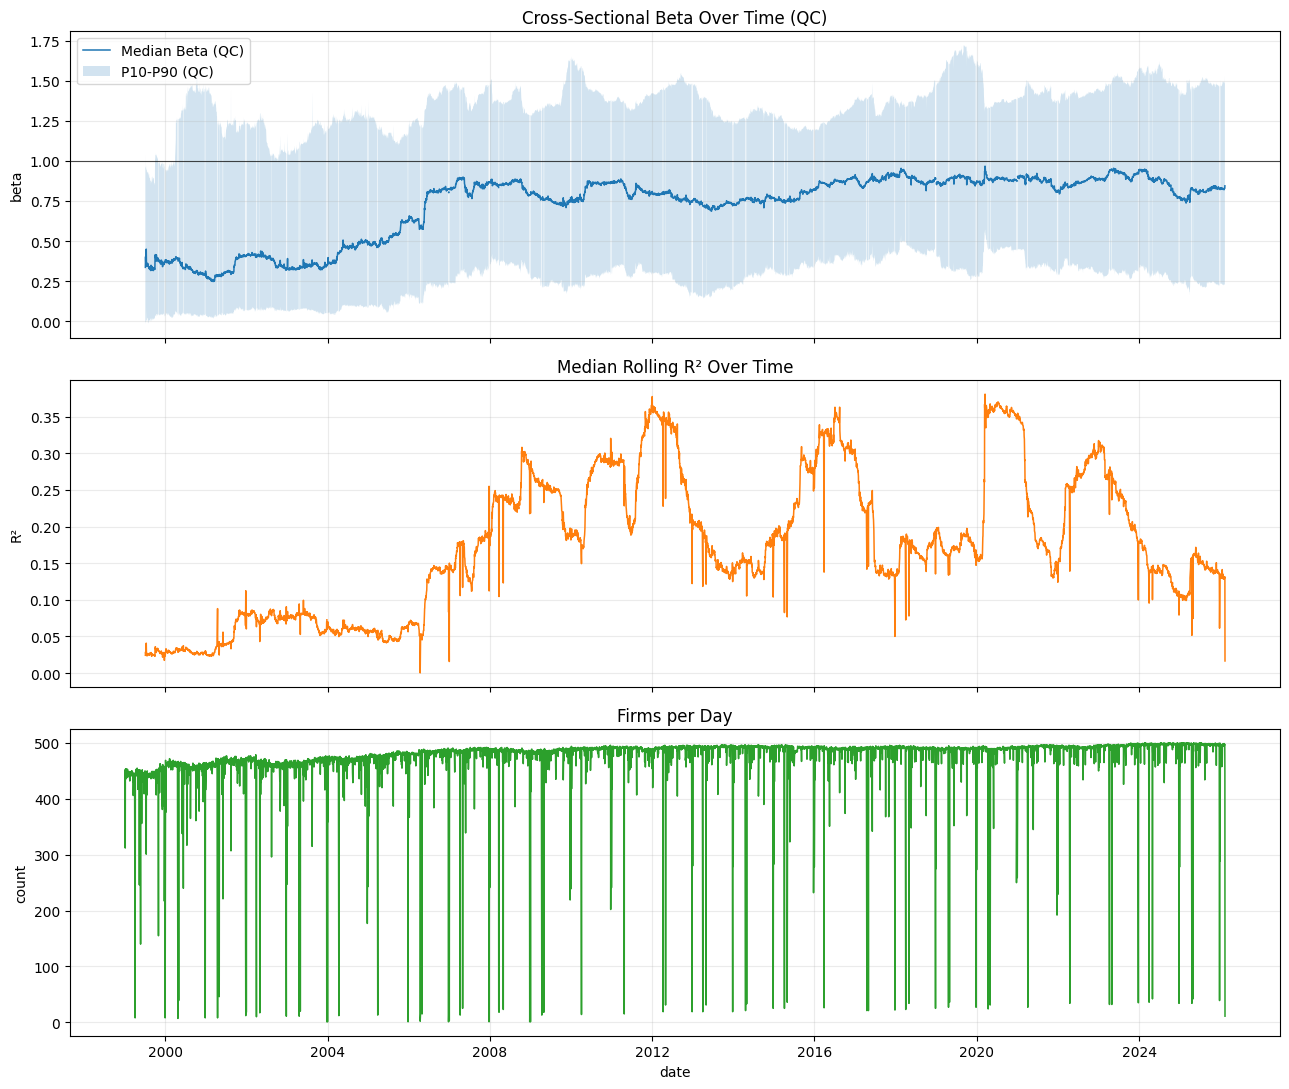

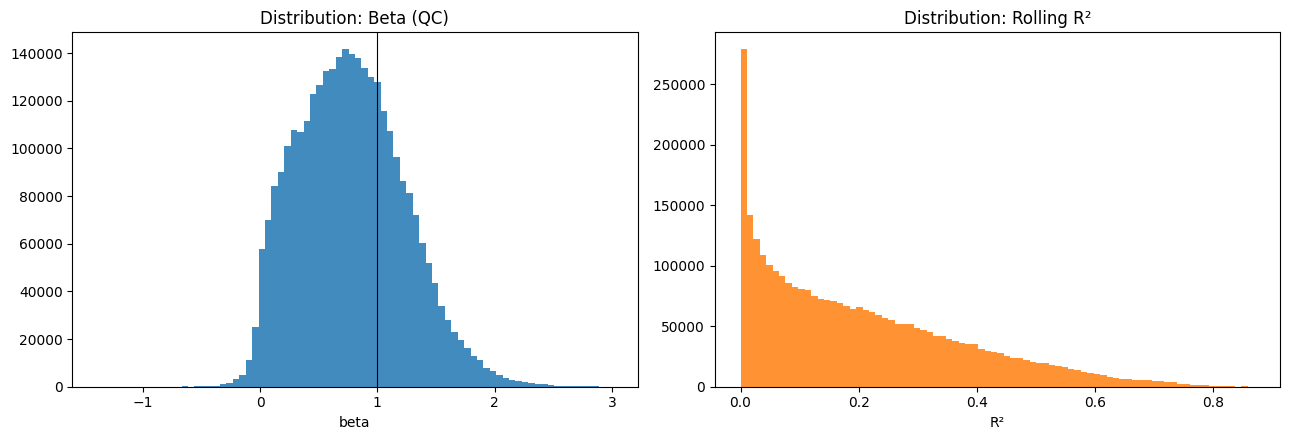

In [22]:

plot_df = analysis_df.dropna(subset=["date"]).copy()

beta_daily_stats = (
    plot_df.groupby("date", as_index=False)
    .agg(
        beta_median=("beta_capm_daily", "median"),
        beta_p10=("beta_capm_daily", lambda s: s.quantile(0.10)),
        beta_p90=("beta_capm_daily", lambda s: s.quantile(0.90)),
        r2_median=("r2_capm_daily", "median"),
        n_firms=("n_firms_day", "max"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(beta_daily_stats["date"], beta_daily_stats["beta_median"], lw=1.1, label="Median Beta (QC)")
axes[0].fill_between(
    beta_daily_stats["date"],
    beta_daily_stats["beta_p10"],
    beta_daily_stats["beta_p90"],
    alpha=0.2,
    label="P10-P90 (QC)",
)
axes[0].axhline(1.0, color="black", lw=0.8, alpha=0.7)
axes[0].set_title("Cross-Sectional Beta Over Time (QC)")
axes[0].set_ylabel("beta")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(beta_daily_stats["date"], beta_daily_stats["r2_median"], color="tab:orange", lw=1.1)
axes[1].set_title("Median Rolling R² Over Time")
axes[1].set_ylabel("R²")
axes[1].grid(alpha=0.25)

axes[2].plot(beta_daily_stats["date"], beta_daily_stats["n_firms"], color="tab:green", lw=1.1)
axes[2].set_title("Firms per Day")
axes[2].set_ylabel("count")
axes[2].set_xlabel("date")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(plot_df["beta_capm_daily"].dropna(), bins=80, color="tab:blue", alpha=0.85)
axes[0].axvline(1.0, color="black", lw=0.8)
axes[0].set_title("Distribution: Beta (QC)")
axes[0].set_xlabel("beta")

axes[1].hist(plot_df["r2_capm_daily"].dropna(), bins=80, color="tab:orange", alpha=0.85)
axes[1].set_title("Distribution: Rolling R²")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()


## 3. EPS Forecasts FY1-FY5 fuer EURO500 laden

Ziel:
- Fuer jeden Eintrag in `euro500` einen As-of EPS-Forecast ziehen
- Horizont `FY1` bis `FY5`
- Ergebnis als `EURO500_EPS.parquet` mit je einer Spalte pro Forecast-Horizont

### Ablauf (robust)
1. Request-Key bauen: `asof_date x pull_ric`
2. Nach Datum gruppiert in Batches ziehen (`BATCH_SIZE`)
3. Pro Batch Checkpoint-Parquet schreiben (auch wenn leer, um Endlosschleifen zu vermeiden)
4. Batch-Fehler via rekursivem Split isolieren und problematische RICs loggen
5. Alle Teile konsolidieren und sauber auf `euro500` zurueck mergen

### Wichtige Schalter
- `FORCE_REFRESH_EPS = True`: ignoriert vorhandene Checkpoints und zieht alles neu
- `FORCE_REFRESH_EPS = False`: nutzt vorhandene Checkpoints (schneller, aber ggf. stale)

### Mapping-Logik für FY1-FY5
LSEG liefert je nach Antwortformat nicht immer explizite FY-Tags im Spaltennamen.
Deshalb wird zweistufig gemappt:
- zuerst ueber Namensmatch (`EPS`, `MEAN`, `FYx`)
- falls nicht eindeutig: Fallback ueber Spaltenreihenfolge nach Instrument

Damit wird verhindert, dass valide EPS-Werte durch uneindeutige Header als `NaN` enden.


In [23]:
# ------------------------------------------------------------
# Step 3 — Robust EPS Forecast Pull (FY1-FY5) with checkpoints
# ------------------------------------------------------------

HORIZONS = ["FY1", "FY2", "FY3", "FY4", "FY5"]
EPS_FIELDS = [f"TR.EPSMean(period={h})" for h in HORIZONS]
BATCH_SIZE = 100
FORCE_REFRESH_EPS = False
MAX_SPLIT_DEPTH = 10

EURO500_EPS_PATH = DATA_DIR / "euro500_x_EPS.parquet"
EPS_CKPT_DIR = DATA_DIR / "eps_checkpoints"
EPS_CKPT_DIR.mkdir(parents=True, exist_ok=True)
EPS_BAD_RICS_LOG = DATA_DIR / "eps_bad_rics.csv"


def _clean_str(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    x = x.where(x.notna() & (x != ""), pd.NA)
    return x


def _asof_from_euro500(df: pd.DataFrame) -> pd.Series:
    if "date" in df.columns:
        return pd.to_datetime(df["date"], errors="coerce").dt.normalize()
    if "formation_date" in df.columns:
        return pd.to_datetime(df["formation_date"], errors="coerce").dt.normalize()
    if "effective_date" in df.columns:
        return pd.to_datetime(df["effective_date"], errors="coerce").dt.normalize()
    raise ValueError("No usable date column found in euro500 (expected date/formation_date/effective_date).")


def _chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i : i + n]


def _ckpt_path(asof: pd.Timestamp, batch_ix: int) -> Path:
    return EPS_CKPT_DIR / f"eps_{asof.strftime('%Y%m%d')}_batch_{batch_ix:04d}.parquet"


def _atomic_to_parquet(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_parquet(tmp, index=False)
    tmp.replace(path)


def _append_bad_rics(bad_list: list[str], asof: pd.Timestamp, reason: str):
    if not bad_list:
        return
    d = pd.DataFrame({"pull_ric": bad_list, "asof_date": pd.to_datetime(asof), "reason": reason})
    if EPS_BAD_RICS_LOG.exists():
        old = pd.read_csv(EPS_BAD_RICS_LOG)
        d = pd.concat([old, d], ignore_index=True)
        d = d.drop_duplicates(subset=["pull_ric", "asof_date", "reason"])
    d.to_csv(EPS_BAD_RICS_LOG, index=False)


def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [
            " | ".join([str(v) for v in tup if v is not None]).strip()
            for tup in x.columns
        ]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _fetch_eps_for_batch(
    batch: list[str],
    asof_str: str,
    asof_date: pd.Timestamp,
    max_split_depth: int = 10,
) -> tuple[pd.DataFrame, list[str]]:
    """
    Fetch EPSMean forecasts for a batch.
    On failure, recursively split batch until success or bad single RIC is identified.
    Returns: (raw_df, bad_rics)
    """
    if not batch:
        return pd.DataFrame(), []

    params = {"SDate": asof_str, "EDate": asof_str}

    try:
        raw = ld.get_data(universe=batch, fields=EPS_FIELDS, parameters=params)
        if raw is None or len(raw) == 0:
            return pd.DataFrame(), []
        return pd.DataFrame(raw), []
    except Exception:
        if len(batch) == 1 or max_split_depth <= 0:
            return pd.DataFrame(), [batch[0]]

        mid = len(batch) // 2
        left = batch[:mid]
        right = batch[mid:]

        df_l, bad_l = _fetch_eps_for_batch(left, asof_str, asof_date, max_split_depth=max_split_depth - 1)
        df_r, bad_r = _fetch_eps_for_batch(right, asof_str, asof_date, max_split_depth=max_split_depth - 1)

        out = []
        if df_l is not None and not df_l.empty:
            out.append(df_l)
        if df_r is not None and not df_r.empty:
            out.append(df_r)

        df_out = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
        return df_out, (bad_l + bad_r)


def _standardize_eps_df(df: pd.DataFrame, asof_date: pd.Timestamp) -> pd.DataFrame:
    """
    Standardize get_data result into columns:
    pull_ric, asof_date, EPS_FY1..EPS_FY5

    Robust to:
    - MultiIndex columns
    - duplicate column names
    - column name variants from LSEG
    """
    out_cols = ["pull_ric", "asof_date"] + [f"EPS_{h}" for h in HORIZONS]
    if df is None or getattr(df, "empty", True):
        return pd.DataFrame(columns=out_cols)

    x = _flatten_columns(df)

    # instrument / ric column
    ric_col = None
    for c in x.columns:
        cl = c.lower()
        if cl in {"instrument", "ric"}:
            ric_col = c
            break
    if ric_col is None:
        for c in x.columns:
            cl = c.lower()
            if "instrument" in cl or cl.endswith("ric"):
                ric_col = c
                break
    if ric_col is None:
        ric_col = x.columns[0]

    std = pd.DataFrame({
        "pull_ric": x[ric_col].astype("string").str.strip(),
        "asof_date": pd.to_datetime(asof_date),
    })

    def _as_series(v):
        if isinstance(v, pd.DataFrame):
            return v.iloc[:, 0]
        return v

    # map each horizon by searching column names first.
    # If provider returns duplicate generic headers (e.g. "Earnings Per Share - Mean"
    # repeated 5x without FY tag), fall back to field order after instrument column.
    ric_pos = list(x.columns).index(ric_col)
    value_pos = [i for i in range(len(x.columns)) if i != ric_pos]

    for h_ix, h in enumerate(HORIZONS):
        target = f"EPS_{h}"
        col_match = None

        # Prefer explicit FY-tagged column names when available.
        for c in x.columns:
            uc = c.upper()
            if ("EPS" in uc) and ("MEAN" in uc) and (h in uc):
                col_match = c
                break
        if col_match is None:
            for c in x.columns:
                uc = c.upper()
                if ("EPS" in uc) and (h in uc):
                    col_match = c
                    break

        if col_match is not None:
            s = _as_series(x[col_match])
            std[target] = pd.to_numeric(s, errors="coerce")
            continue

        # Fallback: assign by ordinal field position (FY1..FY5).
        if h_ix < len(value_pos):
            s = x.iloc[:, value_pos[h_ix]]
            std[target] = pd.to_numeric(s, errors="coerce")
        else:
            std[target] = np.nan

    std["pull_ric"] = _clean_str(std["pull_ric"])
    std = std.dropna(subset=["pull_ric"]).drop_duplicates(subset=["pull_ric", "asof_date"], keep="last")

    return std[out_cols]


# ------------------------------------------------------------
# Build request universe from euro500
# ------------------------------------------------------------
euro500_eps = euro500.copy()
euro500_eps["asof_date"] = _asof_from_euro500(euro500_eps)

if "RIC_current" in euro500_eps.columns:
    ric_current = _clean_str(euro500_eps["RIC_current"])
else:
    ric_current = pd.Series(pd.NA, index=euro500_eps.index, dtype="string")

if "RIC" in euro500_eps.columns:
    ric_raw = _clean_str(euro500_eps["RIC"])
else:
    ric_raw = pd.Series(pd.NA, index=euro500_eps.index, dtype="string")

euro500_eps["pull_ric"] = ric_current.fillna(ric_raw)

req = (
    euro500_eps[["asof_date", "pull_ric"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print("EPS request rows (unique asof_date x pull_ric):", len(req))
print("As-of date range:", req["asof_date"].min(), "to", req["asof_date"].max())


# ------------------------------------------------------------
# Pull with checkpoints + recursive split
# ------------------------------------------------------------
rows = []

by_date = (
    req.groupby("asof_date", sort=True)["pull_ric"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .reset_index()
)

ld.open_session()
try:
    for d_ix, r in by_date.iterrows():
        asof_date = pd.to_datetime(r["asof_date"])
        asof_str = asof_date.strftime("%Y-%m-%d")
        rics = list(r["pull_ric"])

        print(f"[{d_ix+1}/{len(by_date)}] AsOf {asof_str} | RICs={len(rics)}")

        for b_ix, batch in enumerate(_chunks(rics, BATCH_SIZE), start=1):
            ck = _ckpt_path(asof_date, b_ix)

            if ck.exists() and not FORCE_REFRESH_EPS:
                try:
                    part = pd.read_parquet(ck)
                    rows.append(part)
                    continue
                except Exception:
                    try:
                        ck.unlink()
                    except Exception:
                        pass

            raw_df, bad = _fetch_eps_for_batch(
                batch=batch,
                asof_str=asof_str,
                asof_date=asof_date,
                max_split_depth=MAX_SPLIT_DEPTH,
            )

            if bad:
                _append_bad_rics(bad, asof=asof_date, reason="get_data_failed_recursive_split")

            part = _standardize_eps_df(raw_df, asof_date=asof_date)

            # write checkpoint even if empty to avoid endless retries
            _atomic_to_parquet(part, ck)
            rows.append(part)

finally:
    ld.close_session()


# ------------------------------------------------------------
# Consolidate + merge back to euro500 rows
# ------------------------------------------------------------
out_cols = ["pull_ric", "asof_date"] + [f"EPS_{h}" for h in HORIZONS]
if rows:
    eps_panel = pd.concat(rows, ignore_index=True)
else:
    eps_panel = pd.DataFrame(columns=out_cols)

eps_panel["asof_date"] = pd.to_datetime(eps_panel.get("asof_date"), errors="coerce")
eps_panel = eps_panel[eps_panel["asof_date"].notna()].copy()

eps_panel = (
    eps_panel.sort_values(["pull_ric", "asof_date"])
    .drop_duplicates(["pull_ric", "asof_date"], keep="last")
    .reset_index(drop=True)
)

euro500_eps = euro500_eps.merge(eps_panel, on=["pull_ric", "asof_date"], how="left")

euro500_eps.to_parquet(EURO500_EPS_PATH, index=False)

print("Saved:", EURO500_EPS_PATH)
print("Rows:", len(euro500_eps))
print("Unique pull_ric:", euro500_eps["pull_ric"].nunique(dropna=True))
for h in HORIZONS:
    c = f"EPS_{h}"
    miss = int(euro500_eps[c].isna().sum()) if c in euro500_eps.columns else -1
    print(f"Missing {c}: {miss}")
print(f"[INFO] Bad RIC log (if any): {EPS_BAD_RICS_LOG}")



EPS request rows (unique asof_date x pull_ric): 54000
As-of date range: 1998-12-31 00:00:00 to 2025-09-30 00:00:00
[1/108] AsOf 1998-12-31 | RICs=500
[2/108] AsOf 1999-03-31 | RICs=500
[3/108] AsOf 1999-06-30 | RICs=500
[4/108] AsOf 1999-09-30 | RICs=500
[5/108] AsOf 1999-12-31 | RICs=500
[6/108] AsOf 2000-03-31 | RICs=500
[7/108] AsOf 2000-06-30 | RICs=500
[8/108] AsOf 2000-09-29 | RICs=500
[9/108] AsOf 2000-12-29 | RICs=500
[10/108] AsOf 2001-03-30 | RICs=500
[11/108] AsOf 2001-06-29 | RICs=500
[12/108] AsOf 2001-09-28 | RICs=500
[13/108] AsOf 2001-12-31 | RICs=500
[14/108] AsOf 2002-03-29 | RICs=500
[15/108] AsOf 2002-06-28 | RICs=500
[16/108] AsOf 2002-09-30 | RICs=500
[17/108] AsOf 2002-12-31 | RICs=500
[18/108] AsOf 2003-03-31 | RICs=500
[19/108] AsOf 2003-06-30 | RICs=500
[20/108] AsOf 2003-09-30 | RICs=500
[21/108] AsOf 2003-12-31 | RICs=500
[22/108] AsOf 2004-03-31 | RICs=500
[23/108] AsOf 2004-06-30 | RICs=500
[24/108] AsOf 2004-09-30 | RICs=500
[25/108] AsOf 2004-12-31 | RIC

## 4. Long-Term Growth (TR.LTGMean) fuer `euro500_x_EPS` laden

Ziel:
- Fuer jede Request-Kombination `asof_date x pull_ric` den Long-Term-Growth-Mean ziehen
- Feld: `TR.LTGMean`
- Ergebnis als Spalte `LTGMean` in derselben Tabelle `euro500_x_EPS.parquet` speichern

Implementierung:
1. Requests aus `euro500_x_EPS.parquet` bauen (`asof_date`, `pull_ric`)
2. Pull nach Datum in Batches, inkl. Checkpoints
3. Rekursiver Split bei Batch-Fehlern, problematische RICs loggen
4. Merge auf `pull_ric` + `asof_date` und Datei ueberschreiben


In [24]:
# ------------------------------------------------------------
# Step 4 — Robust Long-Term Growth Pull (TR.LTGMean)
#          DailyReturns-style cache + ID fallback
# ------------------------------------------------------------


LTG_FIELD = 'TR.LTGMean'
LTG_COL = 'LTGMean'
FORCE_REFRESH_LTG = False
LTG_MAX_RETRIES = 3
LTG_BASE_SLEEP = 0.4
LTG_ASOF_TOL_DAYS = 120
LTG_BETA_PATH = DATA_DIR / 'daily_returns_beta.parquet'
LTG_BETA_COL = 'beta_capm_daily'
LTG_BETA_TOL_DAYS = 45
LTG_SKIP_FILLED = True

LTG_BAD_RICS_LOG = DATA_DIR / 'ltg_bad_rics.csv'
LTG_CACHE_DIR = DATA_DIR / 'ltg_cache_by_company'
LTG_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

euro500_eps_ltg = pd.read_parquet(EURO500_EPS_PATH).copy()

# Keep prior LTG for explicit before-vs-after coverage comparison.
prev_ltg = pd.to_numeric(euro500_eps_ltg[LTG_COL], errors='coerce') if LTG_COL in euro500_eps_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index)

if 'asof_date' not in euro500_eps_ltg.columns:
    euro500_eps_ltg['asof_date'] = _asof_from_euro500(euro500_eps_ltg)
else:
    euro500_eps_ltg['asof_date'] = pd.to_datetime(euro500_eps_ltg['asof_date'], errors='coerce').dt.normalize()

for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'pull_ric', 'pull_id', 'id_type']:
    if c in euro500_eps_ltg.columns:
        euro500_eps_ltg[c] = _clean_str(euro500_eps_ltg[c])

# Fallback pull_id/id_type if missing.
if 'id_type' not in euro500_eps_ltg.columns:
    euro500_eps_ltg['id_type'] = np.select(
        [euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna()],
        ['ISIN', 'RIC', 'RIC'],
        default=pd.NA,
    )
if 'pull_id' not in euro500_eps_ltg.columns:
    euro500_eps_ltg['pull_id'] = np.select(
        [euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna()],
        [euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index)),
         euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index)),
         euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index))],
        default=pd.NA,
    )

euro500_eps_ltg['id_type'] = _clean_str(euro500_eps_ltg['id_type'])
euro500_eps_ltg['pull_id'] = _clean_str(euro500_eps_ltg['pull_id'])

# Stable company key (close to DailyReturns logic).
if 'company_key' not in euro500_eps_ltg.columns:
    if 'firm_id' in euro500_eps_ltg.columns and euro500_eps_ltg['firm_id'].notna().any():
        euro500_eps_ltg['company_key'] = _clean_str(euro500_eps_ltg['firm_id'])
    else:
        euro500_eps_ltg['company_key'] = _clean_str(euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string')))
        euro500_eps_ltg['company_key'] = euro500_eps_ltg['company_key'].fillna(_clean_str(euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))))
        euro500_eps_ltg['company_key'] = euro500_eps_ltg['company_key'].fillna(_clean_str(euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))))
        euro500_eps_ltg['company_key'] = 'CID:' + euro500_eps_ltg['company_key'].astype('string')
else:
    euro500_eps_ltg['company_key'] = _clean_str(euro500_eps_ltg['company_key'])


def _safe_name(company_key: str) -> str:
    h = hashlib.sha1(company_key.encode('utf-8')).hexdigest()[:12]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', company_key)
    return f"{clean[:80]}__{h}.parquet"


def _cache_path_for_company_id(company_key: str, id_type: str, pull_id: str) -> Path:
    raw = f"{company_key}|{id_type}|{pull_id}"
    h = hashlib.sha1(raw.encode('utf-8')).hexdigest()[:10]
    base = _safe_name(company_key).replace('.parquet', '')
    suffix = re.sub(r'[^A-Za-z0-9._-]', '_', f"{id_type}_{h}")
    return LTG_CACHE_DIR / f"{base}__{suffix}.parquet"


def _cache_path_for_company_legacy(company_key: str) -> Path:
    # Backward-compatible path used by older Step-4 versions.
    return LTG_CACHE_DIR / _safe_name(company_key)


def _load_ltg_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['asof_date', LTG_COL])
    d = pd.read_parquet(path).copy()
    if 'asof_date' in d.columns:
        d['asof_date'] = pd.to_datetime(d['asof_date'], errors='coerce').dt.normalize()
    else:
        d['asof_date'] = pd.NaT
    if LTG_COL not in d.columns:
        d[LTG_COL] = np.nan
    d[LTG_COL] = pd.to_numeric(d[LTG_COL], errors='coerce')
    d = d.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return d[['asof_date', LTG_COL]]


def _save_ltg_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    out = d.copy()
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    out[LTG_COL] = pd.to_numeric(out[LTG_COL], errors='coerce')
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out.to_parquet(tmp, index=False)
    tmp.replace(path)


def _extract_ltg_history(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or len(raw) == 0:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    x = _flatten_columns(pd.DataFrame(raw).copy().reset_index())
    if x.empty:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    # Resolve date column
    date_col = None
    for c in x.columns:
        cl = c.lower()
        if cl == 'date' or 'date' in cl:
            date_col = c
            break
    if date_col is None:
        date_col = x.columns[0]

    # Resolve value column
    id_like = set()
    for c in x.columns:
        cl = c.lower()
        if cl in {'instrument', 'ric', 'isin'} or 'instrument' in cl or cl.endswith('ric') or cl.endswith('isin'):
            id_like.add(c)

    value_cols = [c for c in x.columns if c != date_col and c not in id_like]

    val_col = None
    for c in value_cols:
        uc = c.upper()
        if 'LTG' in uc or 'LONG' in uc or 'TR.LTGMEAN' in uc:
            val_col = c
            break

    if val_col is None:
        for c in value_cols:
            s = pd.to_numeric(x[c], errors='coerce')
            if int(s.notna().sum()) > 0:
                val_col = c
                break

    if val_col is None:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    out = pd.DataFrame({
        'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize(),
        LTG_COL: pd.to_numeric(x[val_col], errors='coerce'),
    })
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date', LTG_COL]]


def _pull_ltg_history_segment(pull_id: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    if pd.isna(start) or pd.isna(end) or start > end:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    # Try quarterly first, then monthly for denser fill if quarterly returns nothing.
    plans = ['quarterly', 'monthly']

    for interval in plans:
        last_err = None
        for r in range(LTG_MAX_RETRIES):
            try:
                raw = ld.get_history(
                    universe=[pull_id],
                    fields=[LTG_FIELD],
                    start=start.strftime('%Y-%m-%d'),
                    end=end.strftime('%Y-%m-%d'),
                    interval=interval,
                )
                out = _extract_ltg_history(raw)
                if not out.empty:
                    return out
                break
            except Exception as e:
                last_err = e
                time.sleep(LTG_BASE_SLEEP * (2 ** r) + random.random() * 0.3)

        if last_err is not None:
            continue

    return pd.DataFrame(columns=['asof_date', LTG_COL])


def _build_id_candidates(row: pd.Series) -> list[tuple[str, str]]:
    """Preferred fallback chain per row: ISIN -> RIC_current -> RIC; primary id first."""
    pairs = [
        ('ISIN', row.get('ISIN', pd.NA)),
        ('RIC', row.get('RIC_current', pd.NA)),
        ('RIC', row.get('RIC', pd.NA)),
    ]

    out = []
    seen = set()
    for id_type, value in pairs:
        if pd.isna(value):
            continue
        v = str(value).strip()
        if not v:
            continue
        key = (id_type, v)
        if key in seen:
            continue
        seen.add(key)
        out.append(key)

    primary_type = str(row.get('id_type', '')).upper().strip()
    primary_id = row.get('pull_id', pd.NA)
    if pd.notna(primary_id):
        pv = str(primary_id).strip()
        if pv:
            pkey = (primary_type, pv)
            if pkey in out:
                out = [pkey] + [x for x in out if x != pkey]
            else:
                out = [pkey] + out

    return out


def _update_company_ltg_cache(company_key: str, id_type: str, pull_id: str, start: pd.Timestamp, end: pd.Timestamp, force_refresh: bool = False) -> pd.DataFrame:
    path = _cache_path_for_company_id(company_key, id_type, pull_id)
    legacy_path = _cache_path_for_company_legacy(company_key)

    if force_refresh:
        cached = pd.DataFrame(columns=['asof_date', LTG_COL])
    else:
        cached_id = _load_ltg_cache(path)
        cached_legacy = _load_ltg_cache(legacy_path) if legacy_path.exists() else pd.DataFrame(columns=['asof_date', LTG_COL])

        if cached_id.empty and cached_legacy.empty:
            cached = pd.DataFrame(columns=['asof_date', LTG_COL])
        elif cached_id.empty:
            cached = cached_legacy.copy()
        elif cached_legacy.empty:
            cached = cached_id.copy()
        else:
            # Merge ID-specific and legacy cache; keep non-null LTG from either source.
            m = cached_id.merge(cached_legacy, on='asof_date', how='outer', suffixes=('_id', '_legacy'))
            m[LTG_COL] = pd.to_numeric(m[f'{LTG_COL}_id'], errors='coerce').combine_first(
                pd.to_numeric(m[f'{LTG_COL}_legacy'], errors='coerce')
            )
            cached = m[['asof_date', LTG_COL]].copy()
            cached = cached.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')

        # Persist merged view so future runs don't miss legacy coverage again.
        if not cached.empty:
            _save_ltg_cache(path, cached)

    segments = []
    if cached.empty:
        segments.append((start, end))
    else:
        cmin = cached['asof_date'].min()
        cmax = cached['asof_date'].max()

        # Hard short-circuit: fully covered range -> no network calls.
        if pd.notna(cmin) and pd.notna(cmax) and (cmin <= start) and (cmax >= end) and (not force_refresh):
            return cached

        if start < cmin:
            segments.append((start, cmin - pd.Timedelta(days=1)))
        if end > cmax:
            segments.append((cmax + pd.Timedelta(days=1), end))

    pulled_parts = []
    segment_marks = []
    for sdt, edt in segments:
        if sdt > edt:
            continue
        part = _pull_ltg_history_segment(pull_id, sdt, edt)
        if not part.empty:
            pulled_parts.append(part)
        # Mark queried span even if no values came back (negative cache).
        segment_marks.append(pd.DataFrame({'asof_date': [sdt, edt], LTG_COL: [np.nan, np.nan]}))

    all_parts = []
    if not cached.empty:
        all_parts.append(cached)
    all_parts.extend(pulled_parts)
    all_parts.extend(segment_marks)

    if all_parts:
        all_df = pd.DataFrame.from_records(
            [rec for part in all_parts for rec in part.to_dict('records')],
            columns=['asof_date', LTG_COL],
        )
    else:
        all_df = cached.copy()

    if (not all_df.empty) or force_refresh:
        _save_ltg_cache(path, all_df)

    # Return ID-specific cache if present; fallback to combined frame.
    out = _load_ltg_cache(path)
    return out if not out.empty else all_df


def _map_history_to_requests(req_dates: pd.Series, hist: pd.DataFrame, tol_days: int = 120) -> pd.DataFrame:
    left = pd.DataFrame({'asof_date': pd.to_datetime(req_dates, errors='coerce').dt.normalize()}).dropna().sort_values('asof_date')
    if left.empty:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    if hist is None or hist.empty:
        left[LTG_COL] = np.nan
        return left

    right = hist[['asof_date', LTG_COL]].copy()
    right['asof_date'] = pd.to_datetime(right['asof_date'], errors='coerce').dt.normalize()
    right[LTG_COL] = pd.to_numeric(right[LTG_COL], errors='coerce')
    right = right.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')

    out = pd.merge_asof(
        left,
        right,
        on='asof_date',
        direction='backward',
        tolerance=pd.Timedelta(days=tol_days),
    )
    return out


# Build unique request rows (company x asof) with row-level identifiers.
req_cols = [c for c in ['company_key', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id', LTG_COL] if c in euro500_eps_ltg.columns]
req_all = (
    euro500_eps_ltg[req_cols]
    .dropna(subset=['company_key', 'asof_date'])
    .drop_duplicates(['company_key', 'asof_date'], keep='last')
    .reset_index(drop=True)
)

if req_all.empty:
    raise ValueError('No valid (company_key, asof_date) rows found for LTG pull.')

if FORCE_REFRESH_LTG or (not LTG_SKIP_FILLED) or (LTG_COL not in req_all.columns):
    req = req_all.copy()
else:
    pending_mask = pd.to_numeric(req_all[LTG_COL], errors='coerce').isna()
    req = req_all[pending_mask].copy()

req['id_candidates'] = req.apply(_build_id_candidates, axis=1) if not req.empty else [[] for _ in range(len(req))]
req['n_id_candidates'] = req['id_candidates'].apply(len) if not req.empty else pd.Series(dtype='int64')

print('LTG request rows total (unique company x asof):', len(req_all))
print('LTG pending rows to pull:', len(req))
if not req.empty:
    print('As-of date range:', req['asof_date'].min(), 'to', req['asof_date'].max())
    print('Unique companies:', req['company_key'].nunique())
    print('ID candidates stats:')
    print(req['n_id_candidates'].describe())
else:
    print('All LTG values already present; skipping LTG network/cache pull loop.')

# Pull loop: DailyReturns-style (company cache + sequential ID fallback).
resolved_rows = []
bad_log_rows = []

companies = req['company_key'].dropna().unique().tolist() if not req.empty else []
companies_total = len(companies)
run_t0 = time.time()

total_cache_hits = 0
total_pull_candidates = 0
total_resolved = 0
total_unresolved = 0

ld.open_session()
try:
    for ix, company_key in enumerate(companies, start=1):
        company_req = req[req['company_key'] == company_key].copy().sort_values('asof_date')
        if company_req.empty:
            continue

        req_dates = company_req['asof_date'].dropna().drop_duplicates().sort_values().reset_index(drop=True)
        if req_dates.empty:
            continue

        start = pd.to_datetime(req_dates.min()).normalize()
        end = pd.to_datetime(req_dates.max()).normalize()

        # Start with empty panel for this company; fill sequentially by candidate rank.
        panel = pd.DataFrame({'asof_date': req_dates})
        panel[LTG_COL] = np.nan
        panel['ltg_rank'] = pd.NA
        panel['ltg_id_type'] = pd.NA
        panel['ltg_pull_id'] = pd.NA

        cands = company_req.iloc[0].get('id_candidates', [])
        company_pull_candidates = 0

        # Candidate loop (ISIN -> RIC_current -> RIC)
        for rank, cand in enumerate(cands, start=1):
            if panel[LTG_COL].notna().all():
                break
            if (not isinstance(cand, (list, tuple))) or len(cand) != 2:
                continue

            cand_type = str(cand[0]).upper().strip()
            cand_id = str(cand[1]).strip()
            if not cand_type or not cand_id:
                continue

            company_pull_candidates += 1

            hist = _update_company_ltg_cache(
                company_key=str(company_key),
                id_type=cand_type,
                pull_id=cand_id,
                start=start,
                end=end,
                force_refresh=FORCE_REFRESH_LTG,
            )

            mapped = _map_history_to_requests(req_dates, hist, tol_days=LTG_ASOF_TOL_DAYS)
            panel = panel.merge(mapped.rename(columns={LTG_COL: f'{LTG_COL}_cand'}), on='asof_date', how='left')

            fill_mask = panel[LTG_COL].isna() & panel[f'{LTG_COL}_cand'].notna()
            panel.loc[fill_mask, LTG_COL] = panel.loc[fill_mask, f'{LTG_COL}_cand']
            panel.loc[fill_mask, 'ltg_rank'] = rank
            panel.loc[fill_mask, 'ltg_id_type'] = cand_type
            panel.loc[fill_mask, 'ltg_pull_id'] = cand_id
            panel = panel.drop(columns=[f'{LTG_COL}_cand'])

        # Diagnostics for this company
        company_resolved = int(panel[LTG_COL].notna().sum())
        company_unresolved = int(panel[LTG_COL].isna().sum())

        total_pull_candidates += company_pull_candidates
        total_resolved += company_resolved
        total_unresolved += company_unresolved

        # Cache hit proxy: if first candidate had cache coverage, no additional candidates needed and good fill.
        if company_pull_candidates <= 1:
            total_cache_hits += company_resolved

        # Store rows
        tmp = panel.copy()
        tmp['company_key'] = company_key
        resolved_rows.extend(tmp[['company_key', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']].to_dict('records'))

        if company_unresolved > 0:
            miss = tmp[tmp[LTG_COL].isna()][['asof_date']].copy()
            miss['company_key'] = company_key
            miss['reason'] = 'no_data_after_fallback'
            miss['n_candidates'] = len(cands)
            bad_log_rows.extend(miss[['company_key', 'asof_date', 'reason', 'n_candidates']].to_dict('records'))

        elapsed = time.time() - run_t0
        print(
            f"[{ix}/{companies_total}] company={str(company_key)[:40]} "
            f"rows={len(req_dates)} cand_used={company_pull_candidates} "
            f"resolved={company_resolved} unresolved={company_unresolved} "
            f"elapsed={elapsed/60:.1f}m"
        )

finally:
    ld.close_session()

print(
    f"Done LTG pull: companies={companies_total}, candidate_calls={total_pull_candidates}, "
    f"resolved={total_resolved}, unresolved={total_unresolved}"
)

ltg_panel = pd.DataFrame(resolved_rows)
if not ltg_panel.empty:
    ltg_panel['asof_date'] = pd.to_datetime(ltg_panel['asof_date'], errors='coerce').dt.normalize()
    ltg_panel[LTG_COL] = pd.to_numeric(ltg_panel[LTG_COL], errors='coerce')
    ltg_panel = (
        ltg_panel.sort_values(['company_key', 'asof_date'])
        .drop_duplicates(['company_key', 'asof_date'], keep='last')
        .reset_index(drop=True)
    )
else:
    ltg_panel = pd.DataFrame(columns=['company_key', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id'])

# Persist bad log (append-safe without pd.concat).
if bad_log_rows:
    bad_df = pd.DataFrame(bad_log_rows)
    if LTG_BAD_RICS_LOG.exists():
        old = pd.read_csv(LTG_BAD_RICS_LOG)
        for c in ['company_key', 'asof_date', 'reason', 'n_candidates']:
            if c not in old.columns:
                old[c] = pd.NA
            if c not in bad_df.columns:
                bad_df[c] = pd.NA
        out_bad = pd.DataFrame.from_records(
            old[['company_key', 'asof_date', 'reason', 'n_candidates']].to_dict('records')
            + bad_df[['company_key', 'asof_date', 'reason', 'n_candidates']].to_dict('records'),
            columns=['company_key', 'asof_date', 'reason', 'n_candidates'],
        )
    else:
        out_bad = bad_df

    out_bad['asof_date'] = pd.to_datetime(out_bad['asof_date'], errors='coerce').dt.normalize()
    out_bad = out_bad.drop_duplicates(subset=['company_key', 'asof_date', 'reason'], keep='last')
    out_bad.to_csv(LTG_BAD_RICS_LOG, index=False)

# Merge LTG back and keep diagnostics columns.
keep_diag_cols = ['ltg_rank', 'ltg_id_type', 'ltg_pull_id']
euro500_eps_ltg = euro500_eps_ltg.drop(columns=[c for c in keep_diag_cols if c in euro500_eps_ltg.columns], errors='ignore')
euro500_eps_ltg = euro500_eps_ltg.merge(
    ltg_panel[['company_key', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']],
    on=['company_key', 'asof_date'],
    how='left',
    suffixes=('', '_new'),
)

if f'{LTG_COL}_new' in euro500_eps_ltg.columns:
    old_ltg_series = pd.to_numeric(euro500_eps_ltg[LTG_COL], errors='coerce') if LTG_COL in euro500_eps_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index)
    new_ltg_series = pd.to_numeric(euro500_eps_ltg[f'{LTG_COL}_new'], errors='coerce')
    euro500_eps_ltg[LTG_COL] = new_ltg_series.combine_first(old_ltg_series)
    euro500_eps_ltg = euro500_eps_ltg.drop(columns=[f'{LTG_COL}_new'])

# attach beta from Step 2 output (daily_returns_beta.parquet)
def _attach_beta_asof_ltg(panel: pd.DataFrame) -> pd.DataFrame:
    if LTG_BETA_COL in panel.columns:
        panel[LTG_BETA_COL] = pd.to_numeric(panel[LTG_BETA_COL], errors='coerce')

    if not LTG_BETA_PATH.exists():
        print(f'Beta file not found, skipping beta merge: {LTG_BETA_PATH}')
        if LTG_BETA_COL not in panel.columns:
            panel[LTG_BETA_COL] = np.nan
        return panel

    req_needed = ['company_key', 'asof_date']
    if any(c not in panel.columns for c in req_needed):
        print('Skipping beta merge in Step 4 (company_key/asof_date missing).')
        if LTG_BETA_COL not in panel.columns:
            panel[LTG_BETA_COL] = np.nan
        return panel

    work = panel.copy().reset_index(drop=True)
    work['_row_id'] = np.arange(len(work))
    work['asof_date'] = pd.to_datetime(work['asof_date'], errors='coerce').dt.normalize()

    def _norm(s: pd.Series) -> pd.Series:
        x = s.astype('string').str.strip()
        return x.where(x.notna() & (x != ''), pd.NA)

    cand_frames = []

    base_ck = _norm(work['company_key'])
    cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': base_ck, 'prio': 0}))

    if 'ISIN' in work.columns:
        isin = _norm(work['ISIN'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'ISIN:' + isin, 'prio': 1}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': isin, 'prio': 2}))

    if 'RIC_current' in work.columns:
        ricc = _norm(work['RIC_current'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'RIC:' + ricc, 'prio': 3}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': ricc, 'prio': 4}))

    if 'RIC' in work.columns:
        ric = _norm(work['RIC'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'RIC:' + ric, 'prio': 5}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': ric, 'prio': 6}))

    req = pd.concat(cand_frames, ignore_index=True)
    req = req.dropna(subset=['date', 'beta_key']).drop_duplicates(['_row_id', 'beta_key'], keep='first')

    if req.empty:
        if LTG_BETA_COL not in panel.columns:
            panel[LTG_BETA_COL] = np.nan
        return panel

    beta = pd.read_parquet(LTG_BETA_PATH, columns=['company_key', 'date', LTG_BETA_COL]).copy()
    beta = beta.rename(columns={'company_key': 'beta_key'})
    beta['beta_key'] = _norm(beta['beta_key'])
    beta['date'] = pd.to_datetime(beta['date'], errors='coerce').dt.normalize()
    beta[LTG_BETA_COL] = pd.to_numeric(beta[LTG_BETA_COL], errors='coerce')
    beta = beta.dropna(subset=['beta_key', 'date']).sort_values(['date', 'beta_key'])

    req['beta_key'] = req['beta_key'].astype(object)
    beta['beta_key'] = beta['beta_key'].astype(object)
    req = req.sort_values(['date', 'beta_key']).reset_index(drop=True)

    matched = pd.merge_asof(
        req,
        beta[['beta_key', 'date', LTG_BETA_COL]],
        on='date',
        by='beta_key',
        direction='backward',
        tolerance=pd.Timedelta(days=LTG_BETA_TOL_DAYS),
    )

    matched = matched.sort_values(['_row_id', 'prio'])
    pick = matched.dropna(subset=[LTG_BETA_COL]).drop_duplicates(['_row_id'], keep='first')

    beta_by_row = pick[['_row_id', LTG_BETA_COL]] if not pick.empty else pd.DataFrame(columns=['_row_id', LTG_BETA_COL])
    work = work.merge(beta_by_row, on='_row_id', how='left', suffixes=('', '_new'))

    if f'{LTG_BETA_COL}_new' in work.columns:
        old_s = pd.to_numeric(work[LTG_BETA_COL], errors='coerce') if LTG_BETA_COL in work.columns else pd.Series(np.nan, index=work.index)
        new_s = pd.to_numeric(work[f'{LTG_BETA_COL}_new'], errors='coerce')
        work[LTG_BETA_COL] = new_s.combine_first(old_s)
        work = work.drop(columns=[f'{LTG_BETA_COL}_new'])
    elif LTG_BETA_COL not in work.columns:
        work[LTG_BETA_COL] = np.nan

    return work.drop(columns=['_row_id'])


euro500_eps_ltg = _attach_beta_asof_ltg(euro500_eps_ltg)

# Save updated file.
euro500_eps_ltg.to_parquet(EURO500_EPS_PATH, index=False)
print('Beta non-null share in euro500_x_EPS:', round(pd.to_numeric(euro500_eps_ltg[LTG_BETA_COL], errors='coerce').notna().mean(), 4) if LTG_BETA_COL in euro500_eps_ltg.columns else np.nan)

# Coverage diagnostics: before vs after overall and explicitly 2015/2025.
post_ltg = pd.to_numeric(euro500_eps_ltg[LTG_COL], errors='coerce')
asof_year = pd.to_datetime(euro500_eps_ltg['asof_date'], errors='coerce').dt.year

def _cov(mask: pd.Series, s: pd.Series) -> float:
    sub = s[mask]
    return float(sub.notna().mean()) if len(sub) > 0 else np.nan

rows = []
for yr in ['ALL', 2015, 2025]:
    if yr == 'ALL':
        m = pd.Series(True, index=euro500_eps_ltg.index)
    else:
        m = (asof_year == yr)
    rows.append({
        'year': yr,
        'rows': int(m.sum()),
        'coverage_before': _cov(m, prev_ltg),
        'coverage_after': _cov(m, post_ltg),
    })

coverage_cmp = pd.DataFrame(rows)
coverage_cmp['delta_pp'] = (coverage_cmp['coverage_after'] - coverage_cmp['coverage_before']) * 100.0

print('Saved:', EURO500_EPS_PATH)
print('Rows:', len(euro500_eps_ltg))
print('Unique company_key:', euro500_eps_ltg['company_key'].nunique(dropna=True))
print('Unique asof_date:', euro500_eps_ltg['asof_date'].nunique(dropna=True))
print('\nLTG coverage before vs after fallback:')
display(coverage_cmp)

if not ltg_panel.empty:
    by_id = (
        ltg_panel[ltg_panel['ltg_id_type'].notna()]
        .groupby('ltg_id_type', as_index=False)
        .agg(rows=('company_key', 'size'))
        .sort_values('rows', ascending=False)
    )
    if not by_id.empty:
        by_id['share'] = by_id['rows'] / by_id['rows'].sum()
    print('Resolved LTG rows by winning identifier type:')
    display(by_id)
else:
    print('No LTG rows were resolved in this run.')


LTG request rows total (unique company x asof): 54000
LTG pending rows to pull: 54000
As-of date range: 1998-12-31 00:00:00 to 2025-09-30 00:00:00
Unique companies: 1249
ID candidates stats:
count    54000.000000
mean         2.235667
std          0.428198
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: n_id_candidates, dtype: float64
[1/1249] company=FIRM0001344 rows=108 cand_used=2 resolved=96 unresolved=12 elapsed=0.0m
[2/1249] company=FIRM0001885 rows=108 cand_used=2 resolved=76 unresolved=32 elapsed=0.0m
[3/1249] company=FIRM0000965 rows=108 cand_used=1 resolved=100 unresolved=8 elapsed=0.0m
[4/1249] company=FIRM0001944 rows=108 cand_used=1 resolved=101 unresolved=7 elapsed=0.0m
[5/1249] company=FIRM0000456 rows=108 cand_used=3 resolved=97 unresolved=11 elapsed=0.0m
[6/1249] company=FIRM0001301 rows=108 cand_used=1 resolved=103 unresolved=5 elapsed=0.0m
[7/1249] company=FIRM0000947 rows=108 cand_used=1 resolved=96

,year,rows,coverage_before,coverage_after,delta_pp
0,ALL,54000,0.0,0.449167,44.916667
1,2015,2000,0.0,0.575500,57.550000
2,2025,1500,0.0,0.266667,26.666667


Resolved LTG rows by winning identifier type:


,ltg_id_type,rows,share
0,ISIN,16540,0.681921
1,RIC,7715,0.318079


## 4A. Vollständigkeitsanalyse EPS und LTG

Diese Sektion prueft die Datenabdeckung nach dem EPS- und LTG-Pull, mit Fokus auf die Entwicklung ueber die Jahre.

Enthaelt:
- Coverage je Jahr fuer `EPS_FY1` bis `EPS_FY5` und `LTGMean`
- Anteil mit mindestens einem EPS-Forecast
- Anteil mit vollstaendigem EPS-Block (`FY1` bis `FY5` alle vorhanden)
- Anteil mit vollstaendigem EPS+LTG-Block



Coverage by year (Step 3+4 outputs):


,year,rows,EPS_FY1_coverage,EPS_FY2_coverage,EPS_FY3_coverage,EPS_FY4_coverage,EPS_FY5_coverage,LTGMean_coverage,eps_any_coverage,eps_all_coverage,eps_ltg_all_coverage
0,1998,500,0.646,0.642,0.56,0.162,0.092,0.110000,0.656000,0.0800,0.0220
1,1999,2000,0.7285,0.7275,0.6025,0.3245,0.1455,0.269500,0.745000,0.1390,0.0895
2,2000,2000,0.754,0.7365,0.6675,0.4175,0.2335,0.251500,0.757500,0.2315,0.0975
3,2001,2000,0.771,0.765,0.699,0.4895,0.265,0.300000,0.773500,0.2635,0.1315
4,2002,2000,0.7615,0.754,0.6915,0.441,0.2375,0.382000,0.764500,0.2325,0.1485
5,2003,2000,0.774,0.765,0.699,0.4445,0.2625,0.381500,0.777500,0.2610,0.1790
6,2004,2000,0.798,0.791,0.7145,0.442,0.3025,0.392000,0.805000,0.2985,0.2110
7,2005,2000,0.8,0.7925,0.721,0.39,0.2455,0.358000,0.812000,0.2390,0.1640
8,2006,2000,0.8495,0.8405,0.7525,0.366,0.269,0.355000,0.851000,0.2605,0.1765
9,2007,2000,0.8855,0.8795,0.8085,0.473,0.257,0.362000,0.886000,0.2555,0.1645


10 years with lowest joint EPS+LTG completeness:


,year,eps_ltg_all_coverage
0,1998,0.0220
1,1999,0.0895
2,2000,0.0975
3,2001,0.1315
4,2002,0.1485
7,2005,0.1640
9,2007,0.1645
27,2025,0.1740
8,2006,0.1765
5,2003,0.1790


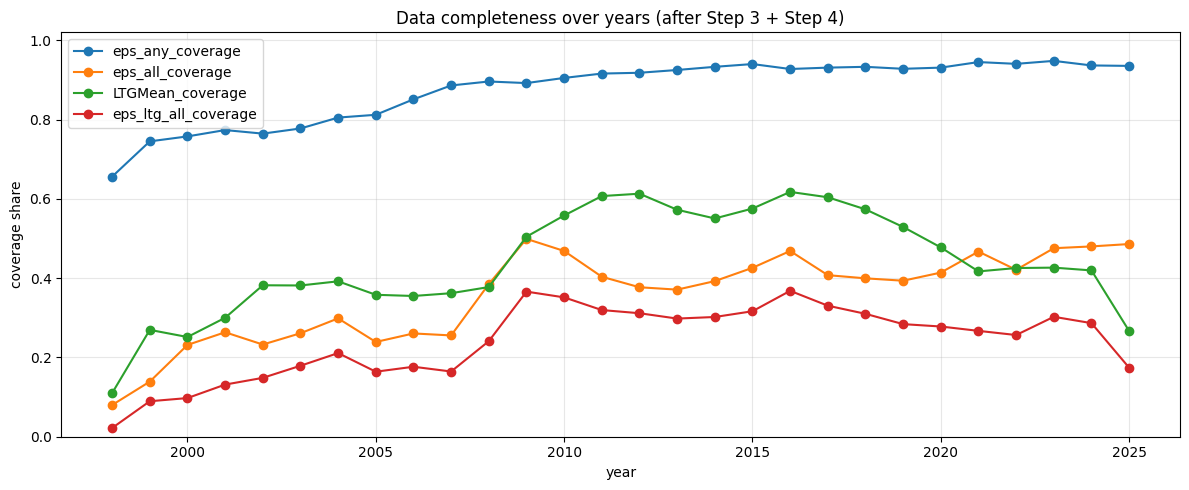

In [25]:

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

cov = pd.read_parquet(EURO500_EPS_PATH).copy()

# Datumsanker fuer Jahresanalyse
if 'asof_date' in cov.columns:
    cov['asof_date'] = pd.to_datetime(cov['asof_date'], errors='coerce')
else:
    cov['asof_date'] = _asof_from_euro500(cov)

cov = cov[cov['asof_date'].notna()].copy()
if cov.empty:
    raise ValueError('No valid asof_date values found for completeness analysis.')

cov['year'] = cov['asof_date'].dt.year

eps_cols = [f'EPS_{h}' for h in HORIZONS]
for c in eps_cols + [LTG_COL]:
    if c not in cov.columns:
        cov[c] = np.nan
    cov[c] = pd.to_numeric(cov[c], errors='coerce')

cov['eps_any'] = cov[eps_cols].notna().any(axis=1)
cov['eps_all'] = cov[eps_cols].notna().all(axis=1)
cov['eps_ltg_all'] = cov['eps_all'] & cov[LTG_COL].notna()

agg = {'rows': ('year', 'size')}
for c in eps_cols + [LTG_COL]:
    agg[f'{c}_non_null'] = (c, lambda s: int(s.notna().sum()))
for c in ['eps_any', 'eps_all', 'eps_ltg_all']:
    agg[f'{c}_non_null'] = (c, lambda s: int(s.sum()))

by_year = cov.groupby('year', as_index=False).agg(**agg)

# Coverage-Raten ergaenzen
for c in eps_cols + [LTG_COL, 'eps_any', 'eps_all', 'eps_ltg_all']:
    by_year[f'{c}_coverage'] = by_year[f'{c}_non_null'] / by_year['rows']

# Lesbare Spaltenauswahl
show_cols = ['year', 'rows']
show_cols += [f'{c}_coverage' for c in eps_cols]
show_cols += [f'{LTG_COL}_coverage', 'eps_any_coverage', 'eps_all_coverage', 'eps_ltg_all_coverage']

print('Coverage by year (Step 3+4 outputs):')
display(by_year[show_cols].sort_values('year'))

# Schwachstellen: schlechteste Jahre
worst = (
    by_year[['year', 'eps_ltg_all_coverage']]
    .sort_values('eps_ltg_all_coverage', ascending=True)
    .head(10)
)
print('10 years with lowest joint EPS+LTG completeness:')
display(worst)

# Plot: Zeitverlauf der wichtigsten Coverage-Metriken
plot_cols = [
    'eps_any_coverage',
    'eps_all_coverage',
    f'{LTG_COL}_coverage',
    'eps_ltg_all_coverage',
]

fig, ax = plt.subplots(figsize=(12, 5))
for col in plot_cols:
    ax.plot(by_year['year'], by_year[col], marker='o', label=col)

ax.set_title('Data completeness over years (after Step 3 + Step 4)')
ax.set_xlabel('year')
ax.set_ylabel('coverage share')
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()




## 4B. LTG Analyse (Qualitaet und Plausibilitaet)

Diese Sektion analysiert die neu gezogene Spalte `LTGMean` in `euro500_x_EPS.parquet`.

Checks:
- Abdeckung (overall + über Zeit)
- Verteilung (raw und winsorized)
- Plausibilitaets-Baender (z. B. LTG < -100% oder > 100%)
- Querschnitt nach Sektor und Land


,rows_total,ltg_non_null,ltg_missing,coverage_share,ltg_lt_-1_count,ltg_gt_+1_count
0,54000,24255,29745,0.449167,2056,21445


LTGMean describe (raw):


count    24255.000000
mean        12.443287
std         18.763160
min       -212.000000
1%         -23.200000
5%          -5.381300
25%          5.000000
50%         10.000000
75%         16.130000
95%         37.941600
99%         77.523000
max        612.870000
Name: LTGMean, dtype: float64

LTGMean describe (winsorized 1%-99%):


count    24255.000000
mean        12.179496
std         14.241380
min        -23.200000
1%         -23.200000
5%          -5.381300
25%          5.000000
50%         10.000000
75%         16.130000
95%         37.941600
99%         77.510580
max         77.523000
Name: LTGMean, dtype: float64

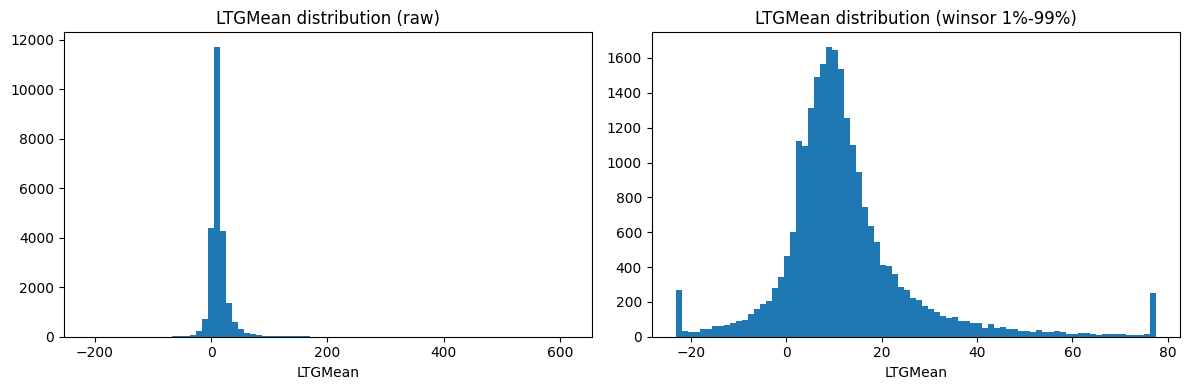

,year,rows,non_null,median,p10,p90,coverage
0,1998,500,55,12.800000,5.211000,21.730000,0.1100
1,1999,2000,539,13.000000,5.100000,24.615334,0.2695
2,2000,2000,503,15.895000,7.216000,31.630000,0.2515
3,2001,2000,600,14.900000,5.950930,31.250000,0.3000
4,2002,2000,764,11.735835,3.725500,25.119000,0.3820
5,2003,2000,763,10.357500,2.830000,19.894500,0.3815
6,2004,2000,784,10.420000,3.469250,22.245000,0.3920
7,2005,2000,716,9.528335,2.897500,25.935000,0.3580
8,2006,2000,710,9.661250,2.890000,23.140500,0.3550
9,2007,2000,724,10.000000,2.500000,24.500000,0.3620


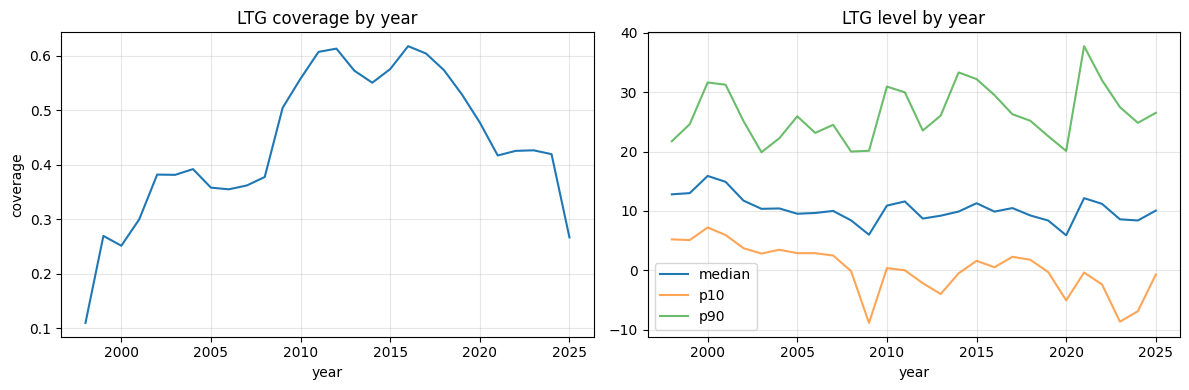

By trbc_sector:


,trbc_sector,n,non_null,median,mean,coverage
4,Energy,2607,1343,6.82333,11.281283,0.515152
6,Industrials,11394,5661,10.85714,13.525701,0.496840
9,Technology,7185,3550,11.03800,12.734811,0.494085
5,Healthcare,4880,2329,10.70000,12.358080,0.477254
2,Consumer Cyclicals,9851,4449,11.33333,15.032279,0.451629
3,Consumer Non-Cyclicals,4667,2028,9.50700,10.611848,0.434540
1,Basic Materials,6225,2671,9.47500,12.211891,0.429076
10,Utilities,3186,1299,5.64000,6.253626,0.407721
8,Real Estate,3971,923,5.50000,7.534262,0.232435
7,"Institutions, Associations & Organizations",29,2,3.32000,3.320000,0.068966


By hq_country:


,hq_country,n,non_null,median,mean,coverage
6,France,12914,6972,10.200000,12.532350,0.539879
7,Germany,11351,6013,10.500000,13.168446,0.529733
14,Netherlands,3719,1886,10.418750,13.839445,0.507126
9,Ireland,2500,1156,11.292000,12.576277,0.462400
18,Spain,4658,1901,9.810000,12.208097,0.408115
0,Austria,2260,903,7.266670,10.809223,0.399558
5,Finland,3262,1260,6.947500,9.797709,0.386266
12,Luxembourg,1304,502,12.221000,14.950105,0.384969
1,Belgium,3487,1188,8.070835,9.414002,0.340694
15,Portugal,1287,423,9.151000,10.643075,0.328671


In [26]:

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

ltg_df = pd.read_parquet(EURO500_EPS_PATH).copy()
if 'LTGMean' not in ltg_df.columns:
    raise KeyError('Column LTGMean not found. Run Step 4 first.')

# Datentypen / Datumsfelder
for dc in ['asof_date', 'date', 'formation_date', 'effective_date']:
    if dc in ltg_df.columns:
        ltg_df[dc] = pd.to_datetime(ltg_df[dc], errors='coerce')

ltg_df['LTGMean'] = pd.to_numeric(ltg_df['LTGMean'], errors='coerce')

if 'asof_date' in ltg_df.columns and ltg_df['asof_date'].notna().any():
    ltg_df['year'] = ltg_df['asof_date'].dt.year
elif 'date' in ltg_df.columns:
    ltg_df['year'] = ltg_df['date'].dt.year
else:
    ltg_df['year'] = pd.NA

# 1) Overall coverage + basic stats
n_total = len(ltg_df)
n_non_null = int(ltg_df['LTGMean'].notna().sum())
n_missing = n_total - n_non_null
coverage = (n_non_null / n_total) if n_total else np.nan

outlier_lo = (ltg_df['LTGMean'] < -1).sum()
outlier_hi = (ltg_df['LTGMean'] > 1).sum()

summary = pd.DataFrame([{
    'rows_total': n_total,
    'ltg_non_null': n_non_null,
    'ltg_missing': n_missing,
    'coverage_share': coverage,
    'ltg_lt_-1_count': int(outlier_lo),
    'ltg_gt_+1_count': int(outlier_hi),
}])
display(summary)

ltg_ok = ltg_df['LTGMean'].dropna()
if len(ltg_ok) > 0:
    print('LTGMean describe (raw):')
    display(ltg_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    p01, p99 = ltg_ok.quantile([0.01, 0.99])
    ltg_w = ltg_ok.clip(lower=p01, upper=p99)
    print('LTGMean describe (winsorized 1%-99%):')
    display(ltg_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(ltg_ok, bins=80)
    ax[0].set_title('LTGMean distribution (raw)')
    ax[0].set_xlabel('LTGMean')

    ax[1].hist(ltg_w, bins=80)
    ax[1].set_title('LTGMean distribution (winsor 1%-99%)')
    ax[1].set_xlabel('LTGMean')
    plt.tight_layout()
    plt.show()
else:
    print('No non-null LTGMean values found.')

# 2) Coverage over time
if 'year' in ltg_df.columns and ltg_df['year'].notna().any():
    cov_year = ltg_df.groupby('year', as_index=False).agg(
        rows=('LTGMean', 'size'),
        non_null=('LTGMean', lambda s: s.notna().sum()),
        median=('LTGMean', 'median'),
        p10=('LTGMean', lambda s: s.quantile(0.10)),
        p90=('LTGMean', lambda s: s.quantile(0.90)),
    )
    cov_year['coverage'] = cov_year['non_null'] / cov_year['rows']
    display(cov_year.head(20))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(cov_year['year'], cov_year['coverage'])
    ax[0].set_title('LTG coverage by year')
    ax[0].set_xlabel('year')
    ax[0].set_ylabel('coverage')
    ax[0].grid(alpha=0.3)

    ax[1].plot(cov_year['year'], cov_year['median'], label='median')
    ax[1].plot(cov_year['year'], cov_year['p10'], label='p10', alpha=0.7)
    ax[1].plot(cov_year['year'], cov_year['p90'], label='p90', alpha=0.7)
    ax[1].set_title('LTG level by year')
    ax[1].set_xlabel('year')
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3) Cross-section by sector / country
for grp_col in ['trbc_sector', 'hq_country']:
    if grp_col in ltg_df.columns:
        g = (
            ltg_df.groupby(grp_col, dropna=False)['LTGMean']
            .agg(n='size', non_null=lambda s: s.notna().sum(), median='median', mean='mean')
            .reset_index()
        )
        g['coverage'] = g['non_null'] / g['n']
        g = g.sort_values(['coverage', 'n'], ascending=[False, False])
        print(f'By {grp_col}:')
        display(g.head(20))


## 5. Modul A:  Annual Balance Sheet (FY)
### Targets laden (`BE`, `assets`, `debt`)

DailyReturns-Prinzip:
- Fallback-ID-Kette: `ISIN -> RIC_current -> RIC`
- Cache pro `company_key` und Kandidat-ID
- Nur fehlende Zeitsegmente werden nachgezogen
- Mapping auf `asof_date` via `merge_asof` (backward, Toleranzfenster)



In [27]:
# ------------------------------------------------------------
# Step 5 — Netpayout Table (clean): BE, assets, debt + beta
#   Input  : euro500.parquet
#   Output : euro500_netpayout.parquet
# ------------------------------------------------------------


# -------------------------
# Config
# -------------------------
BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH = DATA_DIR / 'euro500_netpayout.parquet'
CACHE_DIR = DATA_DIR / 'moduleA_cache_by_company_id'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
BAD_LOG_PATH = DATA_DIR / 'moduleA_bad_ids.csv'
STEP5_ROWS_PATH = DATA_DIR / 'moduleA_step5_rows.parquet'
STEP5_CKPT_PATH = DATA_DIR / 'moduleA_step5_checkpoint.json'

BETA_PATH = DATA_DIR / 'daily_returns_beta.parquet'
BETA_COL = 'beta_capm_daily'

TARGET_FIELDS = {
    'BE': 'TR.F.COMEQTOT(Period=FY0)',
    'assets': 'TR.F.TOTASSETS(Period=FY0)',
    'debt': 'TR.F.DEBTTOT(Period=FY0)',
}
TARGET_COLS = list(TARGET_FIELDS.keys())

ASOF_TOL_DAYS = 365
BETA_TOL_DAYS = 45
MAX_RETRIES = 2
BASE_SLEEP = 1.0
FORCE_REFRESH = False
CACHE_VERSION = 'v2'
DEBUG_FIRST_RAW = True
DEBUG_SHOWN = {'done': False}
DEBUG_VERBOSE = False
DEBUG_MAX_COMPANIES = 15

BATCH_SIZE = 100
BATCH_PAUSE_SEC = 0
MULTI_UNIVERSE_CHUNK = 25

RATE_LIMIT_EVENTS = 0
LAST_GETDATA_ERR_MSG = ""

# LSEG request governor (to avoid 429 storms)
MIN_CALL_INTERVAL_SEC = 0.7
RATE_LIMIT_COOLDOWN_SEC = 3.0
RATE_LIMIT_MULTIPLIER = 1.5
RATE_LIMIT_HARD_PAUSE_SEC = 10.0
RATE_LIMIT_STREAK_TRIGGER = 2
FAIL_FAST_ON_RATE_LIMIT = True
LAST_CALL_TS = 0.0
GLOBAL_COOLDOWN_UNTIL = 0.0
RATE_LIMIT_STREAK = 0

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')

# -------------------------
# Helpers
# -------------------------
def _clean_str(s: pd.Series) -> pd.Series:
    x = s.astype('string').str.strip()
    return x.where(x.notna() & (x != ''), pd.NA)


def _resolve_asof(df: pd.DataFrame) -> pd.Series:
    if 'asof_date' in df.columns:
        return pd.to_datetime(df['asof_date'], errors='coerce').dt.normalize()
    if 'date' in df.columns:
        return pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    if 'formation_date' in df.columns:
        return pd.to_datetime(df['formation_date'], errors='coerce').dt.normalize()
    if 'effective_date' in df.columns:
        return pd.to_datetime(df['effective_date'], errors='coerce').dt.normalize()
    raise ValueError('No usable as-of column found (asof_date/date/formation_date/effective_date).')


def _flatten_cols(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [' | '.join([str(v) for v in tup if v is not None]).strip() for tup in x.columns]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _build_id_candidates(row: pd.Series) -> list[tuple[str, str]]:
    pairs = [
        ('ISIN', row.get('ISIN', pd.NA)),
        ('RIC', row.get('RIC_current', pd.NA)),
        ('RIC', row.get('RIC', pd.NA)),
    ]

    out = []
    seen = set()
    for id_type, value in pairs:
        if pd.isna(value):
            continue
        v = str(value).strip()
        if not v:
            continue
        key = (id_type, v)
        if key in seen:
            continue
        seen.add(key)
        out.append(key)

    primary_type = str(row.get('id_type', '')).upper().strip()
    primary_id = row.get('pull_id', pd.NA)
    if pd.notna(primary_id):
        pv = str(primary_id).strip()
        if pv:
            pkey = (primary_type, pv)
            if pkey in out:
                out = [pkey] + [x for x in out if x != pkey]
            else:
                out = [pkey] + out

    return out


def _cache_file(company_key: str, id_type: str, pull_id: str) -> Path:
    raw = f'{company_key}|{id_type}|{pull_id}'
    h = hashlib.sha1(raw.encode('utf-8')).hexdigest()[:12]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', company_key)
    return CACHE_DIR / f"{clean[:70]}__{id_type}_{h}__{CACHE_VERSION}.parquet"


def _load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)
    d = pd.read_parquet(path).copy()
    d['asof_date'] = pd.to_datetime(d.get('asof_date'), errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        if c not in d.columns:
            d[c] = np.nan
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return d[['asof_date'] + TARGET_COLS]


def _save_cache(path: Path, d: pd.DataFrame) -> None:
    out = d.copy()
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    tmp = path.with_suffix(path.suffix + '.tmp')
    out.to_parquet(tmp, index=False)
    tmp.replace(path)


def _extract_history(raw: pd.DataFrame, value_col_name: str) -> pd.DataFrame:
    if raw is None or len(raw) == 0:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    x = _flatten_cols(pd.DataFrame(raw).reset_index())
    if x.empty:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    date_col = None
    for c in x.columns:
        if 'date' in c.lower() or c.lower() == 'date':
            date_col = c
            break
    if date_col is None:
        date_col = x.columns[0]

    id_like = set()
    for c in x.columns:
        cl = c.lower()
        if c == date_col:
            continue
        if cl in {'instrument', 'ric', 'isin'} or 'instrument' in cl or cl.endswith('ric') or cl.endswith('isin'):
            id_like.add(c)

    value_candidates = [c for c in x.columns if c != date_col and c not in id_like]
    if not value_candidates:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    best = None
    best_n = -1
    for c in value_candidates:
        n = int(pd.to_numeric(x[c], errors='coerce').notna().sum())
        if n > best_n:
            best_n = n
            best = c

    if best is None or best_n <= 0:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    out = pd.DataFrame({
        'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize(),
        value_col_name: pd.to_numeric(x[best], errors='coerce'),
    })
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date', value_col_name]]


def _govern_requests() -> None:
    global LAST_CALL_TS, GLOBAL_COOLDOWN_UNTIL
    now = time.time()
    if now < GLOBAL_COOLDOWN_UNTIL:
        wait = GLOBAL_COOLDOWN_UNTIL - now
        if wait > 0:
            time.sleep(wait)
    now = time.time()
    gap = now - LAST_CALL_TS
    if gap < MIN_CALL_INTERVAL_SEC:
        time.sleep(MIN_CALL_INTERVAL_SEC - gap)


def _cache_covers_range(cached: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> bool:
    if cached is None or cached.empty:
        return False
    cmin = cached['asof_date'].min()
    cmax = cached['asof_date'].max()
    has_any_cached_value = bool(cached[TARGET_COLS].notna().any().any()) if not cached.empty else False
    return bool(pd.notna(cmin) and pd.notna(cmax) and cmin <= start and cmax >= end and has_any_cached_value)


def _call_get_data(universe: list[str], fields: list[str], params: dict, dbg_label: str) -> pd.DataFrame:
    global LAST_CALL_TS, GLOBAL_COOLDOWN_UNTIL, RATE_LIMIT_STREAK, RATE_LIMIT_EVENTS, LAST_GETDATA_ERR_MSG

    LAST_GETDATA_ERR_MSG = ""
    last_err = None
    raw = None
    for r in range(MAX_RETRIES):
        try:
            _govern_requests()
            raw = ld.get_data(universe=universe, fields=fields, parameters=params)
            LAST_CALL_TS = time.time()
            RATE_LIMIT_STREAK = 0
            LAST_GETDATA_ERR_MSG = ""
            break
        except Exception as e:
            LAST_CALL_TS = time.time()
            last_err = e
            LAST_GETDATA_ERR_MSG = str(e)
            msg = str(e)
            is_rate_limit = 'Too many requests' in msg or '429' in msg
            if is_rate_limit:
                RATE_LIMIT_STREAK += 1
                RATE_LIMIT_EVENTS += 1
                cooldown = RATE_LIMIT_COOLDOWN_SEC * (RATE_LIMIT_MULTIPLIER ** r) + random.random()
                if RATE_LIMIT_STREAK >= RATE_LIMIT_STREAK_TRIGGER:
                    cooldown = max(cooldown, RATE_LIMIT_HARD_PAUSE_SEC)
                GLOBAL_COOLDOWN_UNTIL = max(GLOBAL_COOLDOWN_UNTIL, time.time() + cooldown)
                if DEBUG_VERBOSE:
                    print(f'[DEBUG rate limit] id={dbg_label} retry={r+1}/{MAX_RETRIES} streak={RATE_LIMIT_STREAK} cooldown={cooldown:.1f}s err={type(e).__name__}: {e}')
                if FAIL_FAST_ON_RATE_LIMIT:
                    break
                time.sleep(cooldown)
            else:
                RATE_LIMIT_STREAK = 0
                if DEBUG_VERBOSE:
                    print(f'[DEBUG get_data error] id={dbg_label} retry={r+1}/{MAX_RETRIES} err={type(e).__name__}: {e}')
                time.sleep(BASE_SLEEP * (2 ** r) + random.random() * 0.3)

    if raw is None or len(raw) == 0:
        if DEBUG_VERBOSE:
            if last_err is not None:
                print(f'[DEBUG empty raw after errors] id={dbg_label} last_err={type(last_err).__name__}: {last_err} (skipped)')
            else:
                print(f'[DEBUG empty raw no exception] id={dbg_label}')
        return pd.DataFrame()

    return pd.DataFrame(raw)


def _hist_from_flat_frame(x: pd.DataFrame) -> pd.DataFrame:
    if x is None or x.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    x = _flatten_cols(x)
    if x.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    date_col = None
    for c in x.columns:
        uc = c.upper()
        if 'PERIOD' in uc and 'DATE' in uc:
            date_col = c
            break
    if date_col is None:
        for c in x.columns:
            if 'date' in c.lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    out = pd.DataFrame({'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize()})

    def _norm(s: str) -> str:
        return re.sub(r'[^A-Z0-9]', '', str(s).upper())

    def _field_token(field_expr: str) -> str:
        m = re.search(r'TR\.F\.([A-Z0-9_]+)', str(field_expr), flags=re.IGNORECASE)
        return _norm(m.group(1)) if m else _norm(field_expr)

    fallback_tokens = {
        'BE': ['COMEQTOT', 'COMEQ', 'EQUITY', 'COMMONEQUITY', 'BOOKEQUITY'],
        'assets': ['TOTASSETS', 'TOTALASSETS', 'ASSETS'],
        'debt': ['DEBTTOT', 'TOTALDEBT', 'DEBT'],
    }

    norm_cols = {c: _norm(c) for c in x.columns}

    for tgt, field_expr in TARGET_FIELDS.items():
        token = _field_token(field_expr)
        cand = None
        for c, cn in norm_cols.items():
            if token and (token in cn or cn in token):
                cand = c
                break
        if cand is None:
            for alt in fallback_tokens.get(tgt, []):
                alt_n = _norm(alt)
                for c, cn in norm_cols.items():
                    if alt_n and alt_n in cn:
                        cand = c
                        break
                if cand is not None:
                    break
        out[tgt] = pd.to_numeric(x[cand], errors='coerce') if cand is not None else np.nan

    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date'] + TARGET_COLS]


def _pull_targets_segment(pull_id: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    if pd.isna(start) or pd.isna(end) or start > end:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    params = {
        'SDate': start.strftime('%Y-%m-%d'),
        'EDate': end.strftime('%Y-%m-%d'),
        'Frq': 'FY',
    }
    fields = ['TR.F.PeriodEndDate(Period=FY0)'] + list(TARGET_FIELDS.values())

    raw_df = _call_get_data(universe=[pull_id], fields=fields, params=params, dbg_label=pull_id)
    if raw_df.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    if DEBUG_FIRST_RAW and (not DEBUG_SHOWN['done']):
        print('DEBUG first raw get_data shape:', raw_df.shape)
        print('DEBUG first raw columns:', list(raw_df.columns)[:20])
        try:
            nn = raw_df.notna().sum()
            print('DEBUG first raw non-null counts (top):')
            print(nn.head(20))
        except Exception:
            pass
        DEBUG_SHOWN['done'] = True

    return _hist_from_flat_frame(raw_df)


def _pull_targets_multi_segment(pull_ids: list[str], start: pd.Timestamp, end: pd.Timestamp) -> dict[str, pd.DataFrame]:
    if not pull_ids or pd.isna(start) or pd.isna(end) or start > end:
        return {}

    uniq = []
    seen = set()
    for pid in pull_ids:
        v = str(pid).strip()
        if not v:
            continue
        k = v.upper()
        if k in seen:
            continue
        seen.add(k)
        uniq.append(v)

    if not uniq:
        return {}

    params = {
        'SDate': start.strftime('%Y-%m-%d'),
        'EDate': end.strftime('%Y-%m-%d'),
        'Frq': 'FY',
    }
    fields = ['TR.F.PeriodEndDate(Period=FY0)'] + list(TARGET_FIELDS.values())

    out = {pid: pd.DataFrame(columns=['asof_date'] + TARGET_COLS) for pid in uniq}

    def _assign_from_raw(ids: list[str], raw_df: pd.DataFrame) -> None:
        if raw_df is None or raw_df.empty:
            return
        x = _flatten_cols(raw_df)
        if x.empty:
            return

        inst_col = None
        for c in x.columns:
            cl = c.lower()
            if 'instrument' in cl or cl in {'ric', 'isin'}:
                inst_col = c
                break

        if inst_col is None:
            if len(ids) == 1:
                out[ids[0]] = _hist_from_flat_frame(x)
            return

        inst_norm = x[inst_col].astype('string').str.strip().str.upper()
        for pid in ids:
            g = x.loc[inst_norm == str(pid).upper()].copy()
            if g.empty:
                continue
            out[pid] = _hist_from_flat_frame(g)

    def _periodend_collect_error(msg: str) -> bool:
        m = (msg or '').lower()
        return ('unable to collect data for the field' in m) and ('periodenddate' in m)

    def _fetch_ids(ids: list[str]) -> None:
        if not ids:
            return
        label = f'multi[{len(ids)}]:' + ','.join(ids[:3])
        raw_df = _call_get_data(universe=ids, fields=fields, params=params, dbg_label=label)

        if raw_df.empty:
            err = LAST_GETDATA_ERR_MSG
            # Some bad identifiers can poison a whole multi request: split recursively.
            if len(ids) > 1 and _periodend_collect_error(err):
                mid = len(ids) // 2
                left = ids[:mid]
                right = ids[mid:]
                if DEBUG_VERBOSE:
                    print(f'[DEBUG multi split] size={len(ids)} -> {len(left)}+{len(right)} due to PeriodEndDate collect error')
                _fetch_ids(left)
                _fetch_ids(right)
            return

        _assign_from_raw(ids, raw_df)

    for i in range(0, len(uniq), MULTI_UNIVERSE_CHUNK):
        chunk = uniq[i:i+MULTI_UNIVERSE_CHUNK]
        _fetch_ids(chunk)

    return out


def _combine(frames: list[pd.DataFrame]) -> pd.DataFrame:

    recs = []
    for f in frames:
        if f is None or not isinstance(f, pd.DataFrame) or f.empty:
            continue
        g = f.copy()
        for c in ['asof_date'] + TARGET_COLS:
            if c not in g.columns:
                g[c] = np.nan if c != 'asof_date' else pd.NaT
        g = g[['asof_date'] + TARGET_COLS]
        g = g.loc[~g.isna().all(axis=1)]
        if g.empty:
            continue
        recs.extend(g.to_dict('records'))

    if not recs:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    out = pd.DataFrame.from_records(recs, columns=['asof_date'] + TARGET_COLS)
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    return out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')


def _update_cache(company_key: str, id_type: str, pull_id: str, start: pd.Timestamp, end: pd.Timestamp, force_refresh: bool = False) -> pd.DataFrame:
    path = _cache_file(company_key, id_type, pull_id)
    cached = pd.DataFrame(columns=['asof_date'] + TARGET_COLS) if force_refresh else _load_cache(path)

    segments = []
    if cached.empty:
        segments.append((start, end))
    else:
        cmin = cached['asof_date'].min()
        cmax = cached['asof_date'].max()
        has_any_cached_value = bool(cached[TARGET_COLS].notna().any().any()) if not cached.empty else False
        # short-circuit only if cache covers range AND contains at least one real value
        if pd.notna(cmin) and pd.notna(cmax) and cmin <= start and cmax >= end and has_any_cached_value and (not force_refresh):
            return cached
        if start < cmin:
            segments.append((start, cmin - pd.Timedelta(days=1)))
        if end > cmax:
            segments.append((cmax + pd.Timedelta(days=1), end))

    pulled = []
    for sdt, edt in segments:
        if sdt > edt:
            continue
        seg = _pull_targets_segment(pull_id, sdt, edt)
        if not seg.empty:
            pulled.append(seg)

    combined = _combine([cached] + pulled)
    if not combined.empty or force_refresh:
        _save_cache(path, combined)

    out = _load_cache(path)
    return out if not out.empty else combined


def _map_to_asof(req_dates: pd.Series, hist: pd.DataFrame, tol_days: int) -> pd.DataFrame:
    left = pd.DataFrame({'asof_date': pd.to_datetime(req_dates, errors='coerce').dt.normalize()}).dropna().sort_values('asof_date')
    if left.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    if hist is None or hist.empty:
        for c in TARGET_COLS:
            left[c] = np.nan
        return left

    right = hist[['asof_date'] + TARGET_COLS].copy().sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out = pd.merge_asof(
        left,
        right,
        on='asof_date',
        direction='backward',
        tolerance=pd.Timedelta(days=ASOF_TOL_DAYS),
    )
    return out


def _attach_beta_asof(panel: pd.DataFrame) -> pd.DataFrame:
    if BETA_COL in panel.columns:
        panel[BETA_COL] = pd.to_numeric(panel[BETA_COL], errors='coerce')

    if not BETA_PATH.exists():
        print(f'Beta file not found, skipping beta merge: {BETA_PATH}')
        if BETA_COL not in panel.columns:
            panel[BETA_COL] = np.nan
        return panel

    req_needed = ['company_key', 'asof_date']
    if any(c not in panel.columns for c in req_needed):
        if BETA_COL not in panel.columns:
            panel[BETA_COL] = np.nan
        return panel

    work = panel.copy().reset_index(drop=True)
    work['_row_id'] = np.arange(len(work))
    work['asof_date'] = pd.to_datetime(work['asof_date'], errors='coerce').dt.normalize()

    def _norm(s: pd.Series) -> pd.Series:
        x = s.astype('string').str.strip()
        return x.where(x.notna() & (x != ''), pd.NA)

    cand_frames = []
    base_ck = _norm(work['company_key'])
    cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': base_ck, 'prio': 0}))

    if 'ISIN' in work.columns:
        isin = _norm(work['ISIN'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'ISIN:' + isin, 'prio': 1}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': isin, 'prio': 2}))

    if 'RIC_current' in work.columns:
        ricc = _norm(work['RIC_current'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'RIC:' + ricc, 'prio': 3}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': ricc, 'prio': 4}))

    if 'RIC' in work.columns:
        ric = _norm(work['RIC'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'RIC:' + ric, 'prio': 5}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': ric, 'prio': 6}))

    req = pd.concat(cand_frames, ignore_index=True)
    req = req.dropna(subset=['date', 'beta_key']).drop_duplicates(['_row_id', 'beta_key'], keep='first')

    if req.empty:
        panel[BETA_COL] = np.nan
        return panel

    beta = pd.read_parquet(BETA_PATH, columns=['company_key', 'date', BETA_COL]).copy()
    beta = beta.rename(columns={'company_key': 'beta_key'})
    beta['beta_key'] = _norm(beta['beta_key'])
    beta['date'] = pd.to_datetime(beta['date'], errors='coerce').dt.normalize()
    beta[BETA_COL] = pd.to_numeric(beta[BETA_COL], errors='coerce')
    beta = beta.dropna(subset=['beta_key', 'date']).sort_values(['date', 'beta_key'])

    req['beta_key'] = req['beta_key'].astype(object)
    beta['beta_key'] = beta['beta_key'].astype(object)
    req = req.sort_values(['date', 'beta_key']).reset_index(drop=True)

    matched = pd.merge_asof(
        req,
        beta[['beta_key', 'date', BETA_COL]],
        on='date',
        by='beta_key',
        direction='backward',
        tolerance=pd.Timedelta(days=BETA_TOL_DAYS),
    )

    matched = matched.sort_values(['_row_id', 'prio'])
    pick = matched.dropna(subset=[BETA_COL]).drop_duplicates(['_row_id'], keep='first')

    beta_by_row = pick[['_row_id', BETA_COL]] if not pick.empty else pd.DataFrame(columns=['_row_id', BETA_COL])
    work = work.merge(beta_by_row, on='_row_id', how='left', suffixes=('', '_new'))

    if f'{BETA_COL}_new' in work.columns:
        old_s = pd.to_numeric(work[BETA_COL], errors='coerce') if BETA_COL in work.columns else pd.Series(np.nan, index=work.index)
        new_s = pd.to_numeric(work[f'{BETA_COL}_new'], errors='coerce')
        work[BETA_COL] = new_s.combine_first(old_s)
        work = work.drop(columns=[f'{BETA_COL}_new'])
    elif BETA_COL not in work.columns:
        work[BETA_COL] = np.nan

    return work.drop(columns=['_row_id'])


# -------------------------
# Build base request panel
# -------------------------
base = pd.read_parquet(BASE_PATH).copy()
base['asof_date'] = _resolve_asof(base)

for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id', 'company_key']:
    if c in base.columns:
        base[c] = _clean_str(base[c])

if 'id_type' not in base.columns:
    base['id_type'] = np.select(
        [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
        ['ISIN', 'RIC', 'RIC'],
        default=pd.NA,
    )
if 'pull_id' not in base.columns:
    base['pull_id'] = np.select(
        [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
        [base.get('ISIN', pd.Series(pd.NA, index=base.index)),
         base.get('RIC_current', pd.Series(pd.NA, index=base.index)),
         base.get('RIC', pd.Series(pd.NA, index=base.index))],
        default=pd.NA,
    )
base['id_type'] = _clean_str(base['id_type'])
base['pull_id'] = _clean_str(base['pull_id'])

if 'company_key' not in base.columns:
    if 'firm_id' in base.columns and base['firm_id'].notna().any():
        base['company_key'] = _clean_str(base['firm_id'])
    else:
        ck = _clean_str(base.get('ISIN', pd.Series(pd.NA, index=base.index, dtype='string')))
        ck = ck.fillna(_clean_str(base.get('RIC_current', pd.Series(pd.NA, index=base.index, dtype='string'))))
        ck = ck.fillna(_clean_str(base.get('RIC', pd.Series(pd.NA, index=base.index, dtype='string'))))
        base['company_key'] = 'CID:' + ck.astype('string')

req_cols = [c for c in ['company_key', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id'] if c in base.columns]
req = (
    base[req_cols]
    .dropna(subset=['company_key', 'asof_date'])
    .drop_duplicates(['company_key', 'asof_date'], keep='last')
    .reset_index(drop=True)
)
if req.empty:
    raise ValueError('No valid (company_key, asof_date) rows found for Step 5.')

req['id_candidates'] = req.apply(_build_id_candidates, axis=1)
req['n_id_candidates'] = req['id_candidates'].apply(len)

print('Step 5 request rows (company x asof):', len(req))
print('As-of range:', req['asof_date'].min(), 'to', req['asof_date'].max())
print('Unique companies:', req['company_key'].nunique())
print('Pull mode: get_data FY (annual only)')
print('Cache version:', CACHE_VERSION)
print('Active LSEG fields:', TARGET_FIELDS)
print('ID fallback order: ISIN -> RIC_current -> RIC')

# -------------------------
# Pull loop (batched + resume)
# -------------------------
companies_all = req['company_key'].dropna().unique().tolist()
N_total = len(companies_all)

existing_step_rows = pd.DataFrame(columns=['company_key', 'asof_date'] + TARGET_COLS)
if STEP5_ROWS_PATH.exists():
    try:
        existing_step_rows = pd.read_parquet(STEP5_ROWS_PATH)
        if 'asof_date' in existing_step_rows.columns:
            existing_step_rows['asof_date'] = pd.to_datetime(existing_step_rows['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS:
            if c not in existing_step_rows.columns:
                existing_step_rows[c] = np.nan
            existing_step_rows[c] = pd.to_numeric(existing_step_rows[c], errors='coerce')
        existing_step_rows = existing_step_rows[['company_key', 'asof_date'] + TARGET_COLS].dropna(subset=['company_key', 'asof_date'])
        existing_step_rows = existing_step_rows.drop_duplicates(['company_key', 'asof_date'], keep='last')
    except Exception as e:
        print(f'Warning: failed to read STEP5 rows cache, continuing empty: {e}')
        existing_step_rows = pd.DataFrame(columns=['company_key', 'asof_date'] + TARGET_COLS)

processed_from_rows = set(existing_step_rows['company_key'].dropna().astype(str).unique().tolist()) if not existing_step_rows.empty else set()
processed_from_ckpt = set()
if STEP5_CKPT_PATH.exists():
    try:
        ck = json.loads(STEP5_CKPT_PATH.read_text())
        processed_from_ckpt = set(str(x) for x in ck.get('processed_companies', []) if str(x).strip())
    except Exception as e:
        print(f'Warning: failed to read checkpoint, ignoring: {e}')

processed_companies = set(processed_from_rows) | set(processed_from_ckpt)
companies = [c for c in companies_all if str(c) not in processed_companies]
N = len(companies)

print('Resume info: total_companies=', N_total, 'already_processed=', len(processed_companies), 'remaining=', N)
if STEP5_ROWS_PATH.exists():
    print('Resume rows cache:', STEP5_ROWS_PATH, 'rows:', len(existing_step_rows))
if STEP5_CKPT_PATH.exists():
    print('Resume checkpoint:', STEP5_CKPT_PATH)

run_t0 = time.time()
new_rows_out = []
bad_rows = []

total_cand_calls = 0
total_all3_resolved = 0
total_not_all3 = 0
total_item_found = {c: 0 for c in TARGET_COLS}

ld.open_session()
try:
    if N == 0:
        print('No remaining companies to pull in Step 5.')

    n_batches = int(np.ceil(N / BATCH_SIZE)) if N > 0 else 0
    for b_ix, b_start in enumerate(range(0, N, BATCH_SIZE), start=1):
        b_end = min(N, b_start + BATCH_SIZE)
        batch_companies = companies[b_start:b_end]
        batch_t0 = time.time()
        batch_new_rows = []
        batch_processed = []
        batch_deferred = []

        print(f'[BATCH {b_ix}/{n_batches}] companies={len(batch_companies)} idx={b_start+1}-{b_end}')

        company_specs = []
        for j, company_key in enumerate(batch_companies, start=1):
            q = req[req['company_key'] == company_key].copy().sort_values('asof_date')
            dates = q['asof_date'].dropna().drop_duplicates().sort_values().reset_index(drop=True)
            if dates.empty:
                continue

            start = pd.to_datetime(dates.min()).normalize()
            end = pd.to_datetime(dates.max()).normalize()

            cands = q.iloc[0].get('id_candidates', [])
            cand_entries = []
            for cand in cands:
                if (not isinstance(cand, (list, tuple))) or len(cand) != 2:
                    continue
                id_type = str(cand[0]).upper().strip()
                pull_id = str(cand[1]).strip()
                if not id_type or not pull_id:
                    continue
                path = _cache_file(str(company_key), id_type, pull_id)
                cached = pd.DataFrame(columns=['asof_date'] + TARGET_COLS) if FORCE_REFRESH else _load_cache(path)
                needs_pull = (not _cache_covers_range(cached, start, end))
                cand_entries.append({
                    'company_key': str(company_key),
                    'id_type': id_type,
                    'pull_id': pull_id,
                    'start': start,
                    'end': end,
                    'path': path,
                    'cached': cached,
                    'needs_pull': needs_pull,
                })

            company_specs.append({
                'company_key': str(company_key),
                'q': q,
                'dates': dates,
                'cand_entries': cand_entries,
            })

            if j == len(batch_companies):
                # --------- batch prefetch for missing IDs ---------
                need_by_id = {}
                for spec in company_specs:
                    for e in spec['cand_entries']:
                        if not e['needs_pull']:
                            continue
                        pid = e['pull_id']
                        if pid not in need_by_id:
                            need_by_id[pid] = {'start': e['start'], 'end': e['end']}
                        else:
                            need_by_id[pid]['start'] = min(need_by_id[pid]['start'], e['start'])
                            need_by_id[pid]['end'] = max(need_by_id[pid]['end'], e['end'])

                pulled_hist = {}
                if need_by_id:
                    # Group by shared windows to preserve efficiency
                    bucket = {}
                    for pid, w in need_by_id.items():
                        key = (w['start'], w['end'])
                        bucket.setdefault(key, []).append(pid)

                    for (w_start, w_end), ids in bucket.items():
                        total_cand_calls += len(ids)
                        got = _pull_targets_multi_segment(ids, w_start, w_end)
                        for pid, hist in got.items():
                            pulled_hist[pid] = hist

                # merge pulled histories into per-company cache files
                for spec in company_specs:
                    for e in spec['cand_entries']:
                        if not e['needs_pull']:
                            continue
                        hist = pulled_hist.get(e['pull_id'], pd.DataFrame(columns=['asof_date'] + TARGET_COLS))
                        combined = _combine([e['cached'], hist])
                        if not combined.empty or FORCE_REFRESH:
                            _save_cache(e['path'], combined)

                # --------- company mapping from cache ---------
                for k, spec in enumerate(company_specs, start=1):
                    company_key = spec['company_key']
                    q = spec['q']
                    dates = spec['dates']
                    panel = pd.DataFrame({'asof_date': dates})
                    for c in TARGET_COLS:
                        panel[c] = np.nan

                    cand_used = 0
                    rate_events_before = RATE_LIMIT_EVENTS

                    for e in spec['cand_entries']:
                        if panel[TARGET_COLS].notna().all(axis=1).all():
                            break
                        cand_used += 1

                        hist = _load_cache(e['path'])
                        if DEBUG_VERBOSE and b_ix == 1 and k <= DEBUG_MAX_COMPANIES:
                            nn = {c: int(pd.to_numeric(hist[c], errors='coerce').notna().sum()) for c in TARGET_COLS} if (hist is not None and not hist.empty) else {c:0 for c in TARGET_COLS}
                            hmin = hist['asof_date'].min() if (hist is not None and not hist.empty) else pd.NaT
                            hmax = hist['asof_date'].max() if (hist is not None and not hist.empty) else pd.NaT
                            print(f'[DEBUG cand] company={company_key} cand={e["id_type"]}:{e["pull_id"]} hist_rows={0 if hist is None else len(hist)} hist_min={hmin} hist_max={hmax} nn={nn}')

                        mapped = _map_to_asof(panel['asof_date'], hist, tol_days=ASOF_TOL_DAYS)
                        if mapped.empty:
                            continue

                        for c in TARGET_COLS:
                            if c not in mapped.columns:
                                continue
                            cur = pd.to_numeric(panel[c], errors='coerce')
                            nxt = pd.to_numeric(mapped[c], errors='coerce')
                            panel[c] = cur.where(cur.notna(), nxt)

                    panel.insert(0, 'company_key', company_key)
                    recs = panel[['company_key', 'asof_date'] + TARGET_COLS].to_dict('records')
                    new_rows_out.extend(recs)
                    batch_new_rows.extend(recs)

                    all3_resolved = int(panel[TARGET_COLS].notna().all(axis=1).sum())
                    not_all3 = int(len(panel) - all3_resolved)
                    item_found = {c: int(panel[c].notna().sum()) for c in TARGET_COLS}
                    total_all3_resolved += all3_resolved
                    total_not_all3 += not_all3
                    for c in TARGET_COLS:
                        total_item_found[c] += item_found[c]

                    rate_limited_here = (RATE_LIMIT_EVENTS > rate_events_before)
                    if rate_limited_here and sum(item_found.values()) == 0:
                        batch_deferred.append(str(company_key))
                    else:
                        batch_processed.append(str(company_key))

                    unresolved = panel[panel[TARGET_COLS].isna().any(axis=1)]
                    if not unresolved.empty:
                        bad_rows.extend(
                            unresolved[['company_key', 'asof_date']]
                            .assign(reason='not_all3_resolved', n_candidates=int(q['n_id_candidates'].max() if 'n_id_candidates' in q.columns else 0))
                            .to_dict('records')
                        )

                    elapsed = time.time() - run_t0
                    print(
                        f'[{b_start+k}/{N}] company={str(company_key)[:40]} rows={len(dates)} '
                        f'cand_used={cand_used} all3_resolved={all3_resolved} not_all3={not_all3} '
                        f'found_BE={item_found.get("BE",0)} found_assets={item_found.get("assets",0)} found_debt={item_found.get("debt",0)} '
                        f'elapsed={elapsed/60:.1f}m'
                    )
                    if DEBUG_VERBOSE and b_ix == 1 and k <= DEBUG_MAX_COMPANIES:
                        print('[DEBUG panel non-null]', {c: int(panel[c].notna().sum()) for c in TARGET_COLS})
        # Persist batch rows for resume
        if batch_new_rows:
            batch_df = pd.DataFrame(batch_new_rows)
            batch_df['asof_date'] = pd.to_datetime(batch_df['asof_date'], errors='coerce').dt.normalize()
            for c in TARGET_COLS:
                batch_df[c] = pd.to_numeric(batch_df[c], errors='coerce')
            batch_df = batch_df.dropna(subset=['company_key', 'asof_date'])

            if STEP5_ROWS_PATH.exists():
                prev = pd.read_parquet(STEP5_ROWS_PATH)
                if prev is None or prev.empty:
                    combined = batch_df.copy()
                else:
                    prev = prev.copy()
                    prev['asof_date'] = pd.to_datetime(prev.get('asof_date'), errors='coerce').dt.normalize()
                    for c in TARGET_COLS:
                        if c not in prev.columns:
                            prev[c] = np.nan
                        prev[c] = pd.to_numeric(prev[c], errors='coerce')
                    prev = prev[['company_key', 'asof_date'] + TARGET_COLS].dropna(subset=['company_key', 'asof_date'])
                    combined = pd.concat([prev, batch_df], ignore_index=True)
            else:
                combined = batch_df.copy()

            combined = combined.sort_values(['company_key', 'asof_date']).drop_duplicates(['company_key', 'asof_date'], keep='last')
            combined.to_parquet(STEP5_ROWS_PATH, index=False)

        # Persist checkpoint
        processed_companies.update(batch_processed)
        ckpt_payload = {
            'processed_companies': sorted(processed_companies),
            'last_batch': b_ix,
            'remaining_companies': max(0, N_total - len(processed_companies)),
            'rate_limit_events': int(RATE_LIMIT_EVENTS),
            'deferred_companies_last_batch': sorted(set(batch_deferred)),
            'updated_at_utc': pd.Timestamp.utcnow().isoformat(),
        }
        STEP5_CKPT_PATH.write_text(json.dumps(ckpt_payload, ensure_ascii=False, indent=2))

        batch_elapsed = (time.time() - batch_t0) / 60
        print(
            f'[BATCH {b_ix}/{n_batches} DONE] processed={len(batch_processed)} deferred={len(batch_deferred)} '
            f'rate_limit_events_total={RATE_LIMIT_EVENTS} batch_elapsed={batch_elapsed:.1f}m'
        )

        if b_end < N and BATCH_PAUSE_SEC > 0:
            print(f'[BATCH PAUSE] sleeping {BATCH_PAUSE_SEC:.0f}s before next batch...')
            time.sleep(BATCH_PAUSE_SEC)
finally:
    ld.close_session()

print(
    f'Done Step 5: total_companies={N_total}, run_remaining_start={N}, candidate_calls={total_cand_calls}, '
    f'all3_resolved_rows={total_all3_resolved}, not_all3_rows={total_not_all3}, '
    f'found_BE={total_item_found.get("BE",0)}, found_assets={total_item_found.get("assets",0)}, found_debt={total_item_found.get("debt",0)}, '
    f'rate_limit_events={RATE_LIMIT_EVENTS}'
)

rebuild_output = FORCE_REFRESH or (N > 0) or (not STEP5_ROWS_PATH.exists()) or (not OUTPUT_PATH.exists())
if (not rebuild_output) and BASE_PATH.exists() and OUTPUT_PATH.exists():
    rebuild_output = BASE_PATH.stat().st_mtime > OUTPUT_PATH.stat().st_mtime

# -------------------------
# Build final output table
# -------------------------
if rebuild_output and STEP5_ROWS_PATH.exists():
    out_panel = pd.read_parquet(STEP5_ROWS_PATH)
else:
    out_panel = pd.DataFrame(new_rows_out)

if rebuild_output and out_panel.empty:
    out_panel = pd.DataFrame(columns=['company_key', 'asof_date'] + TARGET_COLS)
elif rebuild_output:
    out_panel['asof_date'] = pd.to_datetime(out_panel['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        if c not in out_panel.columns:
            out_panel[c] = np.nan
        out_panel[c] = pd.to_numeric(out_panel[c], errors='coerce')
    out_panel = out_panel[['company_key', 'asof_date'] + TARGET_COLS]
    out_panel = out_panel.sort_values(['company_key', 'asof_date']).drop_duplicates(['company_key', 'asof_date'], keep='last')

if rebuild_output:
    out = base.merge(out_panel, on=['company_key', 'asof_date'], how='left', suffixes=('', '_new'))
    for c in TARGET_COLS:
        if f'{c}_new' in out.columns:
            old_s = pd.to_numeric(out[c], errors='coerce') if c in out.columns else pd.Series(np.nan, index=out.index)
            new_s = pd.to_numeric(out[f'{c}_new'], errors='coerce')
            out[c] = new_s.combine_first(old_s)
            out = out.drop(columns=[f'{c}_new'])

    out = _attach_beta_asof(out)
    out.to_parquet(OUTPUT_PATH, index=False)

    print('Saved netpayout output:', OUTPUT_PATH, 'rows:', len(out))
    euro500_netpayout_df = out.copy()
    print('Data Wrangler variable ready: euro500_netpayout_df')
    print('Beta non-null share in output:', round(pd.to_numeric(out[BETA_COL], errors='coerce').notna().mean(), 4) if BETA_COL in out.columns else np.nan)
else:
    out = pd.read_parquet(OUTPUT_PATH)
    print('Skipped Step-5 rebuild (already up-to-date):', OUTPUT_PATH, 'rows:', len(out))
    euro500_netpayout_df = out.copy()
    print('Data Wrangler variable ready: euro500_netpayout_df')
    print('Beta non-null share in output:', round(pd.to_numeric(out[BETA_COL], errors='coerce').notna().mean(), 4) if BETA_COL in out.columns else np.nan)

if bad_rows:
    bad_df = pd.DataFrame(bad_rows)
    if BAD_LOG_PATH.exists():
        old = pd.read_csv(BAD_LOG_PATH)
        for c in ['company_key', 'asof_date', 'reason', 'n_candidates']:
            if c not in old.columns:
                old[c] = pd.NA
            if c not in bad_df.columns:
                bad_df[c] = pd.NA
        out_bad = pd.DataFrame.from_records(
            old[['company_key', 'asof_date', 'reason', 'n_candidates']].to_dict('records')
            + bad_df[['company_key', 'asof_date', 'reason', 'n_candidates']].to_dict('records'),
            columns=['company_key', 'asof_date', 'reason', 'n_candidates'],
        )
    else:
        out_bad = bad_df

    out_bad['asof_date'] = pd.to_datetime(out_bad['asof_date'], errors='coerce').dt.normalize()
    out_bad = out_bad.drop_duplicates(subset=['company_key', 'asof_date', 'reason'], keep='last')
    out_bad.to_csv(BAD_LOG_PATH, index=False)
    print('Updated bad-id log:', BAD_LOG_PATH, 'rows:', len(out_bad))


Step 5 request rows (company x asof): 54000
As-of range: 1998-12-31 00:00:00 to 2025-09-30 00:00:00
Unique companies: 1249
Pull mode: get_data FY (annual only)
Cache version: v2
Active LSEG fields: {'BE': 'TR.F.COMEQTOT(Period=FY0)', 'assets': 'TR.F.TOTASSETS(Period=FY0)', 'debt': 'TR.F.DEBTTOT(Period=FY0)'}
ID fallback order: ISIN -> RIC_current -> RIC
Resume info: total_companies= 1249 already_processed= 1249 remaining= 0
Resume rows cache: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/moduleA_step5_rows.parquet rows: 54000
Resume checkpoint: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/moduleA_step5_checkpoint.json
No remaining companies to pull in Step 5.
Done Step 5: total_companies=1249, run_remaining_start=0, candidate_calls=0, all3_resolved_rows=0, not_all3_rows=0, found_BE=0, found_assets=0, found_debt=0, rate_limit_events=0
Skipped Step-5 rebuild (already up-to-date)

## 5B. Modul A Coverage Analyse (`BE`, `assets`, `debt`)

Coverage-Checks:
- Row-Coverage je Variable
- Coverage über Jahre (asof-year)
- Anteil Zeilen mit allen 3 Variablen gleichzeitig



,rows_total,cov_BE,cov_assets,cov_debt,cov_all3
0,54000,0.94837,0.950407,0.935537,0.933907


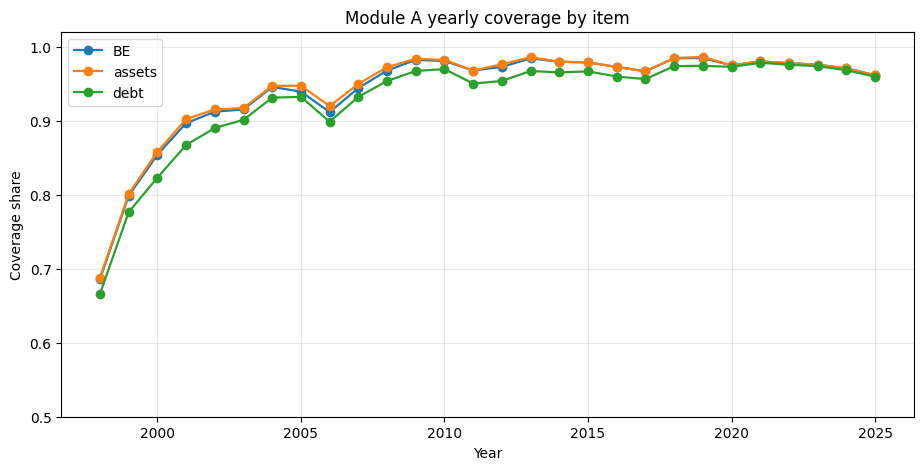

In [28]:

# Robust path resolution for Step 5B (works even after kernel restart)
MODULEA_OUTPUT_PATH = globals().get('OUTPUT_PATH', DATA_DIR / 'euro500_netpayout.parquet')

if not MODULEA_OUTPUT_PATH.exists():
    raise FileNotFoundError(f'Missing file: {MODULEA_OUTPUT_PATH}')

m = pd.read_parquet(MODULEA_OUTPUT_PATH).copy()
for c in ['asof_date']:
    if c in m.columns:
        m[c] = pd.to_datetime(m[c], errors='coerce')

targets = [c for c in ['BE', 'assets', 'debt'] if c in m.columns]
if not targets:
    raise KeyError('No Module A columns found (expected BE/assets/debt). Run Step 5 first.')

for c in targets:
    m[c] = pd.to_numeric(m[c], errors='coerce')

if 'asof_date' in m.columns and m['asof_date'].notna().any():
    m['year'] = m['asof_date'].dt.year
else:
    m['year'] = pd.NA

m['all3_available'] = m[targets].notna().all(axis=1)

# Overall coverage
overall = {'rows_total': len(m)}
for c in targets:
    overall[f'cov_{c}'] = float(m[c].notna().mean()) if len(m) else np.nan
overall['cov_all3'] = float(m['all3_available'].mean()) if len(m) else np.nan

display(pd.DataFrame([overall]))

# Year coverage plot (all three items)
if m['year'].notna().any():
    y = m.groupby('year', as_index=False).agg(rows=('year', 'size'))
    for c in targets:
        y[f'cov_{c}'] = m.groupby('year')[c].apply(lambda s: s.notna().mean()).values
    y['cov_all3'] = m.groupby('year')['all3_available'].apply(lambda s: float(s.mean())).values

    plt.figure(figsize=(11, 5))
    for c in targets:
        plt.plot(y['year'], y[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
    plt.title('Module A yearly coverage by item')
    plt.xlabel('Year')
    plt.ylabel('Coverage share')
    plt.ylim(0.5, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print('No valid year information available for yearly coverage plot.')


## 6. Module B: Annual Income Statement (FY)

### Targets laden (`Sales`, `Net Income`, `Gross Profit`)

LSEG-Items: `TR.F.TotRevenue`, `TR.F.NetIncAfterTax`, `TR.F.CogsTot`

DailyReturns-Prinzip:
- Fallback-ID-Kette: `ISIN -> RIC_current -> RIC`
- Cache pro `company_key` und Kandidat-ID
- Nur fehlende Zeitsegmente werden nachgezogen
- Mapping auf `asof_date` via `merge_asof` (backward, Toleranzfenster)

In [29]:
# ------------------------------------------------------------
# Step 6 — Module B: Income Statement (FY): Sales, NetIncome, GrossProfit + beta
#   Input  : euro500.parquet
#   Output : euro500_income_statement.parquet
# ------------------------------------------------------------

# -------------------------
# Config
# -------------------------
BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH_B = DATA_DIR / 'euro500_income_statement.parquet'

CACHE_DIR_B = DATA_DIR / 'moduleB_cache_by_company_id'
CACHE_DIR_B.mkdir(parents=True, exist_ok=True)
BAD_LOG_PATH_B = DATA_DIR / 'moduleB_bad_ids.csv'
STEP6_ROWS_PATH = DATA_DIR / 'moduleB_step6_rows.parquet'
STEP6_CKPT_PATH = DATA_DIR / 'moduleB_step6_checkpoint.json'

BETA_PATH_B = DATA_DIR / 'daily_returns_beta.parquet'
BETA_COL_B = 'beta_capm_daily'

TARGET_FIELDS_B = {
    'Sales': 'TR.F.TotRevenue(Period=FY0)',
    'NetIncome': 'TR.F.NetIncAfterTax(Period=FY0)',
    'GrossProfit': 'TR.F.GrossProfIndPropTot(Period=FY0)',
    'Cogs': 'TR.F.COGSTot(Period=FY0)',
}
TARGET_COLS_B = list(TARGET_FIELDS_B.keys())
REQUIRED_COLS_B = ['Sales', 'NetIncome', 'GrossProfit']

ASOF_TOL_DAYS_B = 365
BETA_TOL_DAYS_B = 45
MAX_RETRIES_B = 2
BASE_SLEEP_B = 1.0
FORCE_REFRESH_B = False
CACHE_VERSION_B = 'v1'

BATCH_SIZE_B = 100
BATCH_PAUSE_SEC_B = 0
MULTI_UNIVERSE_CHUNK_B = 25

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')


# -------------------------
# Helpers
# -------------------------
def _b_clean_str(s: pd.Series) -> pd.Series:
    x = s.astype('string').str.strip()
    return x.where(x.notna() & (x != ''), pd.NA)


def _b_resolve_asof(df: pd.DataFrame) -> pd.Series:
    if 'asof_date' in df.columns:
        return pd.to_datetime(df['asof_date'], errors='coerce').dt.normalize()
    if 'date' in df.columns:
        return pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    if 'formation_date' in df.columns:
        return pd.to_datetime(df['formation_date'], errors='coerce').dt.normalize()
    if 'effective_date' in df.columns:
        return pd.to_datetime(df['effective_date'], errors='coerce').dt.normalize()
    raise ValueError('No usable as-of column found (asof_date/date/formation_date/effective_date).')


def _b_flatten_cols(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [' | '.join([str(v) for v in tup if v is not None]).strip() for tup in x.columns]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _b_build_id_candidates(row: pd.Series) -> list[tuple[str, str]]:
    isin_val = row.get('ISIN', pd.NA)
    ric_cur = row.get('RIC_current', pd.NA)
    ric_old = row.get('RIC', pd.NA)

    pairs = [
        ('ISIN', f'ISIN:{str(isin_val).strip()}' if pd.notna(isin_val) and str(isin_val).strip() else pd.NA),
        ('ISIN', isin_val),
        ('RIC', ric_cur),
        ('RIC', ric_old),
    ]

    out = []
    seen = set()
    for id_type, value in pairs:
        if pd.isna(value):
            continue
        v = str(value).strip()
        if not v:
            continue
        key = (id_type, v)
        if key in seen:
            continue
        seen.add(key)
        out.append(key)

    primary_type = str(row.get('id_type', '')).upper().strip()
    primary_id = row.get('pull_id', pd.NA)
    if pd.notna(primary_id):
        pv = str(primary_id).strip()
        if pv:
            pkey = (primary_type, pv)
            if pkey in out:
                out = [pkey] + [x for x in out if x != pkey]
            else:
                out = [pkey] + out

    return out


def _b_cache_file(company_key: str, id_type: str, pull_id: str) -> Path:
    raw = f'{company_key}|{id_type}|{pull_id}'
    h = hashlib.sha1(raw.encode('utf-8')).hexdigest()[:12]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', company_key)
    return CACHE_DIR_B / f"{clean[:70]}__{id_type}_{h}__{CACHE_VERSION_B}.parquet"


def _b_load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)
    d = pd.read_parquet(path).copy()
    d = _b_flatten_cols(d)
    if 'asof_date' in d.columns:
        d['asof_date'] = pd.to_datetime(d['asof_date'], errors='coerce').dt.normalize()
    else:
        d['asof_date'] = pd.NaT

    for c in TARGET_COLS_B:
        if c not in d.columns:
            d[c] = np.nan
        d[c] = pd.to_numeric(d[c], errors='coerce')

    d = d.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return d[['asof_date'] + TARGET_COLS_B]


def _b_save_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    out = d.copy()
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS_B:
        if c not in out.columns:
            out[c] = np.nan
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out.to_parquet(tmp, index=False)
    tmp.replace(path)


def _b_cache_covers_range(cached: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> bool:
    if cached is None or cached.empty:
        return False
    cmin = cached['asof_date'].min()
    cmax = cached['asof_date'].max()
    if pd.isna(cmin) or pd.isna(cmax):
        return False

    has_any_cached_value = bool(cached[REQUIRED_COLS_B].notna().any().any())
    if not has_any_cached_value:
        return False

    return bool((cmin <= start) and (cmax >= end))


def _b_combine(parts: list[pd.DataFrame]) -> pd.DataFrame:
    recs = []
    for part in parts:
        if part is None or len(part) == 0:
            continue
        g = _b_flatten_cols(part.copy())
        for c in ['asof_date'] + TARGET_COLS_B:
            if c not in g.columns:
                g[c] = np.nan
        g['asof_date'] = pd.to_datetime(g['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS_B:
            g[c] = pd.to_numeric(g[c], errors='coerce')
        g = g[['asof_date'] + TARGET_COLS_B]
        recs.extend(g.to_dict('records'))

    if not recs:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    out = pd.DataFrame.from_records(recs, columns=['asof_date'] + TARGET_COLS_B)
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out


def _b_extract_targets_history(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or len(raw) == 0:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    x = _b_flatten_cols(pd.DataFrame(raw).copy().reset_index())
    if x.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    date_col = None
    for c in x.columns:
        uc = str(c).upper()
        if 'PERIOD' in uc and 'DATE' in uc:
            date_col = c
            break
    if date_col is None:
        for c in x.columns:
            if 'date' in str(c).lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    out = pd.DataFrame({'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize()})

    def _norm(txt: str) -> str:
        return re.sub(r'[^A-Z0-9]', '', str(txt).upper())

    def _field_token(field_expr: str) -> str:
        m = re.search(r'TR\.F\.([A-Z0-9_]+)', str(field_expr), flags=re.IGNORECASE)
        return _norm(m.group(1)) if m else _norm(field_expr)

    fallback_tokens = {
        'Sales': ['TOTREVENUE', 'REVENUE', 'SALES'],
        'NetIncome': ['NETINCAFTERTAX', 'NETINCOME', 'NETPROFIT'],
        'GrossProfit': ['GROSSPROFINDPROPTOT', 'GROSSPROFIT'],
        'Cogs': ['COGSTOT', 'COGS', 'COSTOFGOODSSOLD'],
    }

    norm_cols = {c: _norm(c) for c in x.columns}

    for tgt, field_expr in TARGET_FIELDS_B.items():
        token = _field_token(field_expr)
        cand = None
        for c, cn in norm_cols.items():
            if token and (token in cn or cn in token):
                cand = c
                break
        if cand is None:
            for alt in fallback_tokens.get(tgt, []):
                alt_n = _norm(alt)
                for c, cn in norm_cols.items():
                    if alt_n and alt_n in cn:
                        cand = c
                        break
                if cand is not None:
                    break
        out[tgt] = pd.to_numeric(x[cand], errors='coerce') if cand is not None else np.nan

    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date'] + TARGET_COLS_B]


def _b_get_data_with_retries(universe: list[str], fields: list[str], params: dict | None = None, dbg_label: str = '') -> pd.DataFrame:
    last_err = None
    for r in range(MAX_RETRIES_B + 1):
        try:
            raw = ld.get_data(universe=universe, fields=fields, parameters=(params or {}))
            return pd.DataFrame(raw)
        except Exception as e:
            last_err = e
            if r >= MAX_RETRIES_B:
                break
            time.sleep(BASE_SLEEP_B * (2 ** r) + random.random() * 0.5)
    # Keep this helper silent; warn once per company if all identifier candidates fail.
    return pd.DataFrame()


def _b_pull_targets_multi_segment(pull_ids: list[str], start: pd.Timestamp, end: pd.Timestamp) -> dict[str, pd.DataFrame]:
    uniq = []
    seen = set()
    for pid in pull_ids:
        p = str(pid).strip()
        if not p or p in seen:
            continue
        seen.add(p)
        uniq.append(p)

    out = {pid: pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B) for pid in uniq}
    if not uniq:
        return out

    fields = ['TR.F.PeriodEndDate'] + list(TARGET_FIELDS_B.values())
    params = {
        'SDate': start.strftime('%Y-%m-%d'),
        'EDate': end.strftime('%Y-%m-%d'),
        'Frq': 'FY',
    }

    for i in range(0, len(uniq), MULTI_UNIVERSE_CHUNK_B):
        chunk = uniq[i:i + MULTI_UNIVERSE_CHUNK_B]
        raw = _b_get_data_with_retries(universe=chunk, fields=fields, params=params, dbg_label=f'chunk={i//MULTI_UNIVERSE_CHUNK_B+1}')
        if raw is None or raw.empty:
            continue

        z = _b_flatten_cols(raw.copy())
        inst_col = None
        for c in z.columns:
            cl = c.lower()
            if cl == 'instrument' or 'instrument' in cl:
                inst_col = c
                break
        if inst_col is None:
            z['instrument'] = chunk[0]
            inst_col = 'instrument'

        for pid in chunk:
            g = z[z[inst_col].astype('string').str.strip() == pid].copy()
            if g.empty:
                continue
            hist = _b_extract_targets_history(g)
            if not hist.empty:
                out[pid] = _b_combine([out[pid], hist])

    return out


def _b_update_company_cache(company_key: str, id_type: str, pull_id: str, start: pd.Timestamp, end: pd.Timestamp, force_refresh: bool = False) -> pd.DataFrame:
    path = _b_cache_file(company_key, id_type, pull_id)
    cached = pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B) if force_refresh else _b_load_cache(path)

    if _b_cache_covers_range(cached, start, end) and (not force_refresh):
        return cached

    pulled = _b_pull_targets_multi_segment([pull_id], start, end).get(pull_id, pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B))
    combined = _b_combine([cached, pulled])
    if not combined.empty or force_refresh:
        _b_save_cache(path, combined)
    return _b_load_cache(path)


def _b_map_to_asof(req_dates: pd.Series, hist: pd.DataFrame, tol_days: int) -> pd.DataFrame:
    left = pd.DataFrame({'asof_date': pd.to_datetime(req_dates, errors='coerce').dt.normalize()}).dropna().sort_values('asof_date')
    if left.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    if hist is None or hist.empty:
        for c in TARGET_COLS_B:
            left[c] = np.nan
        return left

    right = hist[['asof_date'] + TARGET_COLS_B].copy().sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out = pd.merge_asof(
        left,
        right,
        on='asof_date',
        direction='backward',
        tolerance=pd.Timedelta(days=tol_days),
    )
    return out


def _b_attach_beta_asof(panel: pd.DataFrame) -> pd.DataFrame:
    if BETA_COL_B in panel.columns:
        panel[BETA_COL_B] = pd.to_numeric(panel[BETA_COL_B], errors='coerce')

    if not BETA_PATH_B.exists():
        print(f'Beta file not found, skipping beta merge: {BETA_PATH_B}')
        if BETA_COL_B not in panel.columns:
            panel[BETA_COL_B] = np.nan
        return panel

    req_needed = ['company_key', 'asof_date']
    if any(c not in panel.columns for c in req_needed):
        if BETA_COL_B not in panel.columns:
            panel[BETA_COL_B] = np.nan
        return panel

    work = panel.copy().reset_index(drop=True)
    work['_row_id'] = np.arange(len(work))
    work['asof_date'] = pd.to_datetime(work['asof_date'], errors='coerce').dt.normalize()

    def _norm(s: pd.Series) -> pd.Series:
        x = s.astype('string').str.strip()
        return x.where(x.notna() & (x != ''), pd.NA)

    cand_frames = []
    base_ck = _norm(work['company_key'])
    cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': base_ck, 'prio': 0}))

    if 'ISIN' in work.columns:
        isin = _norm(work['ISIN'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'ISIN:' + isin, 'prio': 1}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': isin, 'prio': 2}))

    if 'RIC_current' in work.columns:
        ricc = _norm(work['RIC_current'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'RIC:' + ricc, 'prio': 3}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': ricc, 'prio': 4}))

    if 'RIC' in work.columns:
        ric = _norm(work['RIC'])
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': 'RIC:' + ric, 'prio': 5}))
        cand_frames.append(pd.DataFrame({'_row_id': work['_row_id'], 'date': work['asof_date'], 'beta_key': ric, 'prio': 6}))

    req = pd.concat(cand_frames, ignore_index=True)
    req = req.dropna(subset=['date', 'beta_key']).drop_duplicates(['_row_id', 'beta_key'], keep='first')

    if req.empty:
        panel[BETA_COL_B] = np.nan
        return panel

    beta = pd.read_parquet(BETA_PATH_B, columns=['company_key', 'date', BETA_COL_B]).copy()
    beta = beta.rename(columns={'company_key': 'beta_key'})
    beta['beta_key'] = _norm(beta['beta_key'])
    beta['date'] = pd.to_datetime(beta['date'], errors='coerce').dt.normalize()
    beta[BETA_COL_B] = pd.to_numeric(beta[BETA_COL_B], errors='coerce')
    beta = beta.dropna(subset=['beta_key', 'date']).sort_values(['date', 'beta_key'])

    req['beta_key'] = req['beta_key'].astype(object)
    beta['beta_key'] = beta['beta_key'].astype(object)
    req = req.sort_values(['date', 'beta_key']).reset_index(drop=True)

    matched = pd.merge_asof(
        req,
        beta[['beta_key', 'date', BETA_COL_B]],
        on='date',
        by='beta_key',
        direction='backward',
        tolerance=pd.Timedelta(days=BETA_TOL_DAYS_B),
    )

    matched = matched.sort_values(['_row_id', 'prio'])
    pick = matched.dropna(subset=[BETA_COL_B]).drop_duplicates(['_row_id'], keep='first')

    beta_by_row = pick[['_row_id', BETA_COL_B]] if not pick.empty else pd.DataFrame(columns=['_row_id', BETA_COL_B])
    work = work.merge(beta_by_row, on='_row_id', how='left', suffixes=('', '_new'))

    if f'{BETA_COL_B}_new' in work.columns:
        old_s = pd.to_numeric(work[BETA_COL_B], errors='coerce') if BETA_COL_B in work.columns else pd.Series(np.nan, index=work.index)
        new_s = pd.to_numeric(work[f'{BETA_COL_B}_new'], errors='coerce')
        work[BETA_COL_B] = new_s.combine_first(old_s)
        work = work.drop(columns=[f'{BETA_COL_B}_new'])
    elif BETA_COL_B not in work.columns:
        work[BETA_COL_B] = np.nan

    return work.drop(columns=['_row_id'])


# -------------------------
# Build base request panel
# -------------------------
base_b = pd.read_parquet(BASE_PATH).copy()
base_b['asof_date'] = _b_resolve_asof(base_b)

for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id', 'company_key']:
    if c in base_b.columns:
        base_b[c] = _b_clean_str(base_b[c])

if 'id_type' not in base_b.columns:
    base_b['id_type'] = np.select(
        [base_b.get('ISIN', pd.Series(pd.NA, index=base_b.index)).notna(),
         base_b.get('RIC_current', pd.Series(pd.NA, index=base_b.index)).notna(),
         base_b.get('RIC', pd.Series(pd.NA, index=base_b.index)).notna()],
        ['ISIN', 'RIC', 'RIC'],
        default=pd.NA,
    )
if 'pull_id' not in base_b.columns:
    base_b['pull_id'] = np.select(
        [base_b.get('ISIN', pd.Series(pd.NA, index=base_b.index)).notna(),
         base_b.get('RIC_current', pd.Series(pd.NA, index=base_b.index)).notna(),
         base_b.get('RIC', pd.Series(pd.NA, index=base_b.index)).notna()],
        [base_b.get('ISIN', pd.Series(pd.NA, index=base_b.index)),
         base_b.get('RIC_current', pd.Series(pd.NA, index=base_b.index)),
         base_b.get('RIC', pd.Series(pd.NA, index=base_b.index))],
        default=pd.NA,
    )
base_b['id_type'] = _b_clean_str(base_b['id_type'])
base_b['pull_id'] = _b_clean_str(base_b['pull_id'])

if 'company_key' not in base_b.columns:
    if 'firm_id' in base_b.columns and base_b['firm_id'].notna().any():
        base_b['company_key'] = _b_clean_str(base_b['firm_id'])
    else:
        ck = _b_clean_str(base_b.get('ISIN', pd.Series(pd.NA, index=base_b.index, dtype='string')))
        ck = ck.fillna(_b_clean_str(base_b.get('RIC_current', pd.Series(pd.NA, index=base_b.index, dtype='string'))))
        ck = ck.fillna(_b_clean_str(base_b.get('RIC', pd.Series(pd.NA, index=base_b.index, dtype='string'))))
        base_b['company_key'] = 'CID:' + ck.astype('string')

req_cols_b = [c for c in ['company_key', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id'] if c in base_b.columns]
req_b = (
    base_b[req_cols_b]
    .dropna(subset=['company_key', 'asof_date'])
    .drop_duplicates(['company_key', 'asof_date'], keep='last')
    .reset_index(drop=True)
)
if req_b.empty:
    raise ValueError('No valid (company_key, asof_date) rows found for Step 6.')

req_b['id_candidates'] = req_b.apply(_b_build_id_candidates, axis=1)
req_b['n_id_candidates'] = req_b['id_candidates'].apply(len)

print('Step 6 request rows (company x asof):', len(req_b))
print('As-of range:', req_b['asof_date'].min(), 'to', req_b['asof_date'].max())
print('Unique companies:', req_b['company_key'].nunique())
print('Active LSEG fields:', TARGET_FIELDS_B)
print('ID fallback order: ISIN -> RIC_current -> RIC')


# -------------------------
# Pull loop (batched + resume)
# -------------------------
companies_all_b = req_b['company_key'].dropna().unique().tolist()
N_total_b = len(companies_all_b)

existing_step_rows_b = pd.DataFrame(columns=['company_key', 'asof_date'] + TARGET_COLS_B)
if STEP6_ROWS_PATH.exists():
    try:
        existing_step_rows_b = pd.read_parquet(STEP6_ROWS_PATH)
        if 'asof_date' in existing_step_rows_b.columns:
            existing_step_rows_b['asof_date'] = pd.to_datetime(existing_step_rows_b['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS_B:
            if c not in existing_step_rows_b.columns:
                existing_step_rows_b[c] = np.nan
            existing_step_rows_b[c] = pd.to_numeric(existing_step_rows_b[c], errors='coerce')
        existing_step_rows_b = existing_step_rows_b[['company_key', 'asof_date'] + TARGET_COLS_B].dropna(subset=['company_key', 'asof_date'])
        existing_step_rows_b = existing_step_rows_b.drop_duplicates(['company_key', 'asof_date'], keep='last')
    except Exception as e:
        print(f'Warning: failed to read STEP6 rows cache, continuing empty: {e}')
        existing_step_rows_b = pd.DataFrame(columns=['company_key', 'asof_date'] + TARGET_COLS_B)

processed_from_rows_b = set(existing_step_rows_b['company_key'].dropna().astype(str).unique().tolist()) if not existing_step_rows_b.empty else set()
processed_from_ckpt_b = set()
if STEP6_CKPT_PATH.exists():
    try:
        ck = json.loads(STEP6_CKPT_PATH.read_text())
        processed_from_ckpt_b = set(str(x) for x in ck.get('processed_companies', []) if str(x).strip())
    except Exception as e:
        print(f'Warning: failed to read checkpoint, ignoring: {e}')

processed_companies_b = set(processed_from_rows_b) | set(processed_from_ckpt_b)
companies_b = [c for c in companies_all_b if str(c) not in processed_companies_b]
N_b = len(companies_b)

print('Resume info: total_companies=', N_total_b, 'already_processed=', len(processed_companies_b), 'remaining=', N_b)

run_t0_b = time.time()
new_rows_out_b = []
bad_rows_b = []

total_cand_calls_b = 0
total_all3_resolved_b = 0
total_not_all3_b = 0
total_item_found_b = {c: 0 for c in REQUIRED_COLS_B}

ld.open_session()
try:
    if N_b == 0:
        print('No remaining companies to pull in Step 6.')

    n_batches_b = int(np.ceil(N_b / BATCH_SIZE_B)) if N_b > 0 else 0
    for b_ix, b_start in enumerate(range(0, N_b, BATCH_SIZE_B), start=1):
        b_end = min(N_b, b_start + BATCH_SIZE_B)
        batch_companies = companies_b[b_start:b_end]
        batch_t0 = time.time()
        batch_new_rows = []
        batch_processed = []

        print(f'[BATCH {b_ix}/{n_batches_b}] companies={len(batch_companies)} idx={b_start+1}-{b_end}')

        for k, company_key in enumerate(batch_companies, start=1):
            q = req_b[req_b['company_key'] == company_key].copy().sort_values('asof_date')
            dates = q['asof_date'].dropna().drop_duplicates().sort_values().reset_index(drop=True)
            if dates.empty:
                continue

            start = pd.to_datetime(dates.min()).normalize()
            end = pd.to_datetime(dates.max()).normalize()

            panel = pd.DataFrame({'asof_date': dates})
            for c in TARGET_COLS_B:
                panel[c] = np.nan

            cands = q.iloc[0].get('id_candidates', [])
            cand_used = 0
            attempted_ids = []

            for cand in cands:
                if panel[REQUIRED_COLS_B].notna().all(axis=1).all():
                    break
                if (not isinstance(cand, (list, tuple))) or len(cand) != 2:
                    continue

                id_type = str(cand[0]).upper().strip()
                pull_id = str(cand[1]).strip()
                if not id_type or not pull_id:
                    continue

                cand_used += 1
                total_cand_calls_b += 1
                attempted_ids.append(f'{id_type}:{pull_id}')

                hist = _b_update_company_cache(
                    company_key=str(company_key),
                    id_type=id_type,
                    pull_id=pull_id,
                    start=start,
                    end=end,
                    force_refresh=FORCE_REFRESH_B,
                )
                mapped = _b_map_to_asof(panel['asof_date'], hist, tol_days=ASOF_TOL_DAYS_B)
                if mapped.empty:
                    continue

                for c in TARGET_COLS_B:
                    cur = pd.to_numeric(panel[c], errors='coerce')
                    nxt = pd.to_numeric(mapped.get(c, np.nan), errors='coerce')
                    panel[c] = cur.where(cur.notna(), nxt)

            # GrossProfit fallback: TotRevenue - Cogs
            sales_s = pd.to_numeric(panel['Sales'], errors='coerce')
            gp_s = pd.to_numeric(panel['GrossProfit'], errors='coerce')
            cogs_s = pd.to_numeric(panel['Cogs'], errors='coerce')
            panel['GrossProfit'] = gp_s.combine_first(sales_s - cogs_s)

            panel.insert(0, 'company_key', company_key)
            recs = panel[['company_key', 'asof_date'] + TARGET_COLS_B].to_dict('records')
            new_rows_out_b.extend(recs)
            batch_new_rows.extend(recs)
            batch_processed.append(str(company_key))

            all3_resolved = int(panel[REQUIRED_COLS_B].notna().all(axis=1).sum())
            not_all3 = int(len(panel) - all3_resolved)
            item_found = {c: int(panel[c].notna().sum()) for c in REQUIRED_COLS_B}
            total_all3_resolved_b += all3_resolved
            total_not_all3_b += not_all3
            for c in REQUIRED_COLS_B:
                total_item_found_b[c] += item_found[c]

            any_required_found = bool(panel[REQUIRED_COLS_B].notna().any().any())
            if (not any_required_found) and attempted_ids:
                print(
                    f'[WARN company identifiers unresolved] company={str(company_key)[:40]} '
                    f'ids={attempted_ids[:4]}'
                )

            unresolved = panel[panel[REQUIRED_COLS_B].isna().any(axis=1)]
            if not unresolved.empty:
                bad_rows_b.extend(
                    unresolved[['company_key', 'asof_date']]
                    .assign(reason='not_all3_resolved', n_candidates=int(q['n_id_candidates'].max() if 'n_id_candidates' in q.columns else 0))
                    .to_dict('records')
                )

            elapsed = time.time() - run_t0_b
            print(
                f'[BATCH {b_ix}/{n_batches_b}] [{b_start+k}/{N_b}] company={str(company_key)[:40]} rows={len(dates)} '
                f'cand_used={cand_used} all3_resolved={all3_resolved} not_all3={not_all3} '
                f'found_Sales={item_found.get("Sales",0)} found_NetIncome={item_found.get("NetIncome",0)} found_GrossProfit={item_found.get("GrossProfit",0)} '
                f'elapsed={elapsed/60:.1f}m'
            )

        # Persist batch rows for resume
        if batch_new_rows:
            batch_df = pd.DataFrame(batch_new_rows)
            batch_df['asof_date'] = pd.to_datetime(batch_df['asof_date'], errors='coerce').dt.normalize()
            for c in TARGET_COLS_B:
                batch_df[c] = pd.to_numeric(batch_df[c], errors='coerce')
            batch_df = batch_df.dropna(subset=['company_key', 'asof_date'])

            if STEP6_ROWS_PATH.exists():
                prev = pd.read_parquet(STEP6_ROWS_PATH)
                if prev is None or prev.empty:
                    combined = batch_df.copy()
                else:
                    prev = prev.copy()
                    prev['asof_date'] = pd.to_datetime(prev.get('asof_date'), errors='coerce').dt.normalize()
                    for c in TARGET_COLS_B:
                        if c not in prev.columns:
                            prev[c] = np.nan
                        prev[c] = pd.to_numeric(prev[c], errors='coerce')
                    prev = prev[['company_key', 'asof_date'] + TARGET_COLS_B].dropna(subset=['company_key', 'asof_date'])
                    combined = pd.concat([prev, batch_df], ignore_index=True)
            else:
                combined = batch_df.copy()

            combined = combined.sort_values(['company_key', 'asof_date']).drop_duplicates(['company_key', 'asof_date'], keep='last')
            combined.to_parquet(STEP6_ROWS_PATH, index=False)

        # Persist checkpoint
        processed_companies_b.update(batch_processed)
        ckpt_payload = {
            'processed_companies': sorted(processed_companies_b),
            'last_batch': b_ix,
            'remaining_companies': max(0, N_total_b - len(processed_companies_b)),
            'updated_at_utc': pd.Timestamp.utcnow().isoformat(),
        }
        STEP6_CKPT_PATH.write_text(json.dumps(ckpt_payload, ensure_ascii=False, indent=2))

        batch_elapsed = (time.time() - batch_t0) / 60
        print(f'[BATCH {b_ix}/{n_batches_b} DONE] processed={len(batch_processed)} batch_elapsed={batch_elapsed:.1f}m')

        if b_end < N_b and BATCH_PAUSE_SEC_B > 0:
            print(f'[BATCH PAUSE] sleeping {BATCH_PAUSE_SEC_B:.0f}s before next batch...')
            time.sleep(BATCH_PAUSE_SEC_B)
finally:
    ld.close_session()

print(
    f'Done Step 6: total_companies={N_total_b}, run_remaining_start={N_b}, candidate_calls={total_cand_calls_b}, '
    f'all3_resolved_rows={total_all3_resolved_b}, not_all3_rows={total_not_all3_b}, '
    f'found_Sales={total_item_found_b.get("Sales",0)}, found_NetIncome={total_item_found_b.get("NetIncome",0)}, found_GrossProfit={total_item_found_b.get("GrossProfit",0)}'
)

rebuild_output_b = FORCE_REFRESH_B or (N_b > 0) or (not STEP6_ROWS_PATH.exists()) or (not OUTPUT_PATH_B.exists())
if (not rebuild_output_b) and BASE_PATH.exists() and OUTPUT_PATH_B.exists():
    rebuild_output_b = BASE_PATH.stat().st_mtime > OUTPUT_PATH_B.stat().st_mtime

# -------------------------
# Build final output table
# -------------------------
if rebuild_output_b and STEP6_ROWS_PATH.exists():
    out_panel_b = pd.read_parquet(STEP6_ROWS_PATH)
else:
    out_panel_b = pd.DataFrame(new_rows_out_b)

if rebuild_output_b and out_panel_b.empty:
    out_panel_b = pd.DataFrame(columns=['company_key', 'asof_date'] + TARGET_COLS_B)
elif rebuild_output_b:
    out_panel_b['asof_date'] = pd.to_datetime(out_panel_b['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS_B:
        if c not in out_panel_b.columns:
            out_panel_b[c] = np.nan
        out_panel_b[c] = pd.to_numeric(out_panel_b[c], errors='coerce')

    # Recompute fallback after resume load
    out_panel_b['GrossProfit'] = pd.to_numeric(out_panel_b['GrossProfit'], errors='coerce').combine_first(
        pd.to_numeric(out_panel_b['Sales'], errors='coerce') - pd.to_numeric(out_panel_b['Cogs'], errors='coerce')
    )

    out_panel_b = out_panel_b[['company_key', 'asof_date'] + TARGET_COLS_B]
    out_panel_b = out_panel_b.sort_values(['company_key', 'asof_date']).drop_duplicates(['company_key', 'asof_date'], keep='last')

if rebuild_output_b:
    out_b = base_b.merge(out_panel_b, on=['company_key', 'asof_date'], how='left', suffixes=('', '_new'))
    for c in TARGET_COLS_B:
        if f'{c}_new' in out_b.columns:
            old_s = pd.to_numeric(out_b[c], errors='coerce') if c in out_b.columns else pd.Series(np.nan, index=out_b.index)
            new_s = pd.to_numeric(out_b[f'{c}_new'], errors='coerce')
            out_b[c] = new_s.combine_first(old_s)
            out_b = out_b.drop(columns=[f'{c}_new'])

    # Ensure fallback in final output
    out_b['GrossProfit'] = pd.to_numeric(out_b['GrossProfit'], errors='coerce').combine_first(
        pd.to_numeric(out_b['Sales'], errors='coerce') - pd.to_numeric(out_b['Cogs'], errors='coerce')
    )

    out_b = _b_attach_beta_asof(out_b)

    # Keep requested outputs + beta; Cogs stays internal only
    if 'Cogs' in out_b.columns:
        out_b = out_b.drop(columns=['Cogs'])

    out_b.to_parquet(OUTPUT_PATH_B, index=False)
    euro500_income_statement_df = out_b.copy()

    print('Saved Module-B output:', OUTPUT_PATH_B, 'rows:', len(out_b))
    print('Data Wrangler variable ready: euro500_income_statement_df')
    print('Beta non-null share in output:', round(pd.to_numeric(out_b[BETA_COL_B], errors='coerce').notna().mean(), 4) if BETA_COL_B in out_b.columns else np.nan)
else:
    out_b = pd.read_parquet(OUTPUT_PATH_B)
    euro500_income_statement_df = out_b.copy()
    print('Skipped Step-6 rebuild (already up-to-date):', OUTPUT_PATH_B, 'rows:', len(out_b))
    print('Data Wrangler variable ready: euro500_income_statement_df')
    print('Beta non-null share in output:', round(pd.to_numeric(out_b[BETA_COL_B], errors='coerce').notna().mean(), 4) if BETA_COL_B in out_b.columns else np.nan)

if bad_rows_b:
    bad_df = pd.DataFrame(bad_rows_b)
    if BAD_LOG_PATH_B.exists():
        old = pd.read_csv(BAD_LOG_PATH_B)
        for c in ['company_key', 'asof_date', 'reason', 'n_candidates']:
            if c not in old.columns:
                old[c] = pd.NA
            if c not in bad_df.columns:
                bad_df[c] = pd.NA
        out_bad = pd.DataFrame.from_records(
            old[['company_key', 'asof_date', 'reason', 'n_candidates']].to_dict('records')
            + bad_df[['company_key', 'asof_date', 'reason', 'n_candidates']].to_dict('records'),
            columns=['company_key', 'asof_date', 'reason', 'n_candidates'],
        )
    else:
        out_bad = bad_df

    out_bad['asof_date'] = pd.to_datetime(out_bad['asof_date'], errors='coerce').dt.normalize()
    out_bad = out_bad.drop_duplicates(subset=['company_key', 'asof_date', 'reason'], keep='last')
    out_bad.to_csv(BAD_LOG_PATH_B, index=False)
    print('Updated Module-B bad-id log:', BAD_LOG_PATH_B, 'rows:', len(out_bad))


Step 6 request rows (company x asof): 54000
As-of range: 1998-12-31 00:00:00 to 2025-09-30 00:00:00
Unique companies: 1249
Active LSEG fields: {'Sales': 'TR.F.TotRevenue(Period=FY0)', 'NetIncome': 'TR.F.NetIncAfterTax(Period=FY0)', 'GrossProfit': 'TR.F.GrossProfIndPropTot(Period=FY0)', 'Cogs': 'TR.F.COGSTot(Period=FY0)'}
ID fallback order: ISIN -> RIC_current -> RIC
Resume info: total_companies= 1249 already_processed= 300 remaining= 949
[BATCH 1/10] companies=100 idx=1-100
[BATCH 1/10] [1/949] company=FIRM0000029 rows=108 cand_used=2 all3_resolved=99 not_all3=9 found_Sales=99 found_NetIncome=99 found_GrossProfit=99 elapsed=0.0m
[BATCH 1/10] [2/949] company=FIRM0000391 rows=28 cand_used=2 all3_resolved=17 not_all3=11 found_Sales=17 found_NetIncome=17 found_GrossProfit=17 elapsed=0.5m
[BATCH 1/10] [3/949] company=FIRM0002278 rows=30 cand_used=1 all3_resolved=30 not_all3=0 found_Sales=30 found_NetIncome=30 found_GrossProfit=30 elapsed=0.5m
[BATCH 1/10] [4/949] company=FIRM0001119 rows=30

## 6B. Module B Coverage Analyse (`Sales`, `NetIncome`, `GrossProfit`)

Coverage-Checks:
- Row-Coverage je Variable
- Coverage über Jahre (asof-year)
- Anteil Zeilen mit allen 3 Variablen gleichzeitig



,rows_total,cov_Sales,cov_NetIncome,cov_GrossProfit,cov_all3
0,54000,0.925296,0.925593,0.921685,0.92163


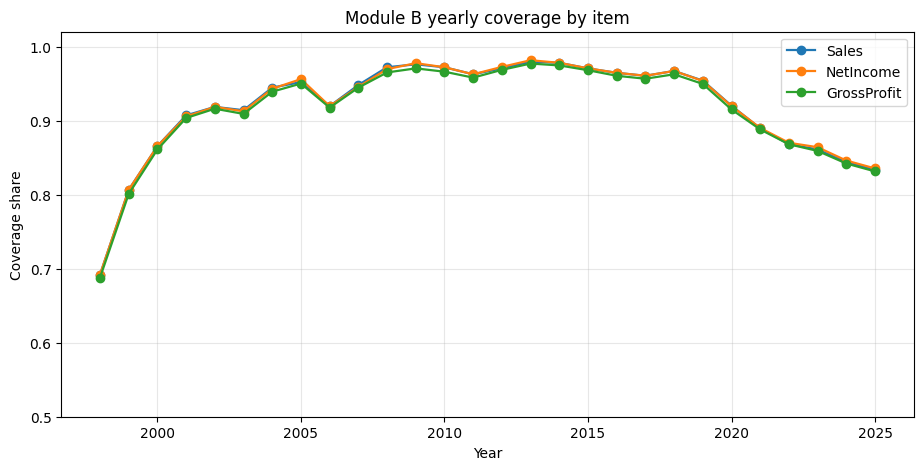

In [30]:
# Robust path resolution for Step 6B
MODULEB_OUTPUT_PATH = globals().get('OUTPUT_PATH_B', DATA_DIR / 'euro500_income_statement.parquet')

if not MODULEB_OUTPUT_PATH.exists():
    raise FileNotFoundError(f'Missing file: {MODULEB_OUTPUT_PATH}')

mb = pd.read_parquet(MODULEB_OUTPUT_PATH).copy()
if 'asof_date' in mb.columns:
    mb['asof_date'] = pd.to_datetime(mb['asof_date'], errors='coerce')

targets_b = [c for c in ['Sales', 'NetIncome', 'GrossProfit'] if c in mb.columns]
if not targets_b:
    raise KeyError('No Module B columns found (expected Sales/NetIncome/GrossProfit). Run Step 6 first.')

for c in targets_b:
    mb[c] = pd.to_numeric(mb[c], errors='coerce')

if 'asof_date' in mb.columns and mb['asof_date'].notna().any():
    mb['year'] = mb['asof_date'].dt.year
else:
    mb['year'] = pd.NA

mb['all3_available'] = mb[targets_b].notna().all(axis=1)

overall_b = {'rows_total': len(mb)}
for c in targets_b:
    overall_b[f'cov_{c}'] = float(mb[c].notna().mean()) if len(mb) else np.nan
overall_b['cov_all3'] = float(mb['all3_available'].mean()) if len(mb) else np.nan

display(pd.DataFrame([overall_b]))

if mb['year'].notna().any():
    yb = mb.groupby('year', as_index=False).agg(rows=('year', 'size'))
    for c in targets_b:
        yb[f'cov_{c}'] = mb.groupby('year')[c].apply(lambda s: s.notna().mean()).values
    yb['cov_all3'] = mb.groupby('year')['all3_available'].apply(lambda s: float(s.mean())).values

    plt.figure(figsize=(11, 5))
    for c in targets_b:
        plt.plot(yb['year'], yb[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
    plt.title('Module B yearly coverage by item')
    plt.xlabel('Year')
    plt.ylabel('Coverage share')
    plt.ylim(0.5, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print('No valid year information available for yearly coverage plot.')


## 7. Modul E: Annual Cashflow / Payouts (FY)

### Targets laden (`Dividends paid`, `Buybacks (net)`)

LSEG-Items: `TR.F.DivPaidCashTotCF`, `TR.F.ComStockBuybackNet`

DailyReturns-Prinzip:
- Fallback-ID-Kette: `ISIN -> RIC_current -> RIC`
- Cache pro `company_key` und Kandidat-ID
- Nur fehlende Zeitsegmente werden nachgezogen
- Mapping auf `asof_date` via `merge_asof` (backward, Toleranzfenster)